
# Integrated Geneformer Lung Cancer Analysis Report

## Normal Lung, LUAD and SCLC Single-Cell Transcriptomics

This notebook combines findings from:
1. T-cell Geneformer analysis
2. Epithelial-cell Geneformer analysis

The goal is to provide a collaborator-friendly report summarizing methods, results, interpretation, limitations, and next steps.



# Executive Summary

### Main findings

- T-cell transcriptomes contain disease-associated immune information but only moderately distinguish Normal, LUAD, and SCLC.
- Epithelial transcriptomes strongly distinguish LUAD from SCLC.
- Tumor epithelial cells carry the strongest lineage-specific signal.
- T-cell states appear to reflect a shared tumor-associated immune microenvironment.
- Geneformer perturbation analysis identified candidate regulators of disease-state transitions.


# Part I: T-cell Analysis

# Annotated Geneformer SCLC/LUAD/Normal T-cell analysis

This notebook explores whether Geneformer can learn disease-associated transcriptional states from lung-derived T cells across normal lung, lung adenocarcinoma (LUAD), and small cell lung carcinoma (SCLC). Comments have been added to clarify the purpose of each analysis stage and to highlight interpretation caveats for collaborators.

# Explore adata

## 1. Import libraries

Load core scientific Python packages, Scanpy for AnnData/scRNA-seq handling, and plotting libraries. This cell does not alter the data.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import os

## 2. Load the full lung cancer single-cell dataset

The input AnnData contains 147,137 cells and 22,021 genes, including tumor and non-tumor cell populations from normal lung, LUAD, and SCLC samples.

In [2]:
adata = sc.read_h5ad("../sclc_raw/5b7cbce2-ed53-47a4-99f8-10af741814e6.h5ad")
adata

AnnData object with n_obs × n_vars = 147137 × 22021
    obs: 'ngenes', 'libsize', 'mito_frac', 'RBP_frac', 'batch', 'donor_id', 'treatment', 'procedure', 'histo', 'cell_type_coarse', 'cell_type_fine', 'cell_type_general', 'clusters', 'cell_type_med', 'H_knn', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'HTAN_Biospecimen_ID', 'HTAN_Participant_ID', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_umap'

## 3. Inspect cell-level metadata

This confirms which sample, disease, tissue, and cell-type annotations are available. These metadata are later used for filtering, donor-level splitting, classification labels, and Geneformer tokenization.

In [3]:
# Explore cell metadata
print("Columns:", adata.obs.columns.tolist())
display(adata.obs.head())
print("Metadata summary:")
display(adata.obs.describe(include="all"))

# Explore unique values of categorical metadata
categorical_cols = [
    col for col in adata.obs.columns
    if adata.obs[col].dtype == "object"
    or str(adata.obs[col].dtype).startswith("category")
    ]
for col in categorical_cols:
    try:
        print(adata.obs[col].value_counts().head(20))
    except:
        print("Cannot display value counts")

display(pd.crosstab(adata.obs["disease"],adata.obs["cell_type"]))

Columns: ['ngenes', 'libsize', 'mito_frac', 'RBP_frac', 'batch', 'donor_id', 'treatment', 'procedure', 'histo', 'cell_type_coarse', 'cell_type_fine', 'cell_type_general', 'clusters', 'cell_type_med', 'H_knn', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'HTAN_Biospecimen_ID', 'HTAN_Participant_ID', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']


,ngenes,libsize,mito_frac,RBP_frac,batch,donor_id,treatment,procedure,histo,cell_type_coarse,...,HTAN_Participant_ID,tissue_type,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
Cell,,,,,,,,,,,,,,,,,,,,,
RU1311A_T_1_165945547864806,255,2.594393,0.055980,0.315522,RU1311A_T_1,RU1311,Platinum Doublet,Biopsy,SCLC,Lymphoid,...,HTA8_2016,tissue,T cell,10x 3' v3,small cell lung carcinoma,female,lung,unknown,77-year-old stage,q1?ma!F=Xe
RU1215_192110488599350,3720,4.285895,0.060109,0.401657,RU1215,RU1215,Naive,Thoracentesis,SCLC,Epithelial,...,HTA8_2012,tissue,epithelial cell,10x 3' v3,small cell lung carcinoma,female,pleural effusion,unknown,75-year-old stage,M!tK?#Xfph
RU1057_T_231270811326245,2293,3.963505,0.030455,0.363389,RU1057_T,RU1057,Naive,Resection,LUAD,Mesenchymal,...,HTA8_1002,tissue,endothelial cell,10x 3' v2,lung adenocarcinoma,female,lung,unknown,67-year-old stage,wUE_o#x^2C
RU1152_130751366121844,5093,4.374162,0.073601,0.185821,RU1152,RU1152,Naive,Biopsy,SCLC,Epithelial,...,HTA8_2009,tissue,epithelial cell,10x 3' v3,small cell lung carcinoma,male,lymph node,unknown,71-year-old stage,!9F#zgnv3I
RU699_227364270922139,1658,3.729489,0.011559,0.218121,RU699,RU699,"Platinum Doublet,Immunotherapy",Resection,LUAD,Lymphoid,...,HTA8_1021,tissue,T cell,10x 3' v2,lung adenocarcinoma,female,adrenal gland,unknown,44-year-old stage,l6CxDWQf>R


Metadata summary:


,ngenes,libsize,mito_frac,RBP_frac,batch,donor_id,treatment,procedure,histo,cell_type_coarse,...,HTAN_Participant_ID,tissue_type,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
count,147137.000000,147137.000000,147137.000000,147137.000000,147137,147137,147137,147137,147137,147137,...,147137,147137,147137,147137,147137,147137,147137,147137,147137,147137
unique,NaN,NaN,NaN,NaN,52,42,9,3,3,4,...,45,1,11,3,3,2,8,3,26,147137
top,NaN,NaN,NaN,NaN,RU1293A,RU1108,Naive,Resection,SCLC,Epithelial,...,HTA8_2005,tissue,epithelial cell,10x 3' v2,small cell lung carcinoma,female,lung,unknown,74-year-old stage,q1?ma!F=Xe
freq,NaN,NaN,NaN,NaN,6484,11294,66888,86272,77143,64301,...,11294,147137,64302,92035,77143,83259,90384,134630,19763,1
mean,2205.696840,3.721064,0.060367,0.245877,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1580.897688,0.508769,0.043701,0.112980,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,36.000000,2.004321,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1011.000000,3.469380,0.026598,0.163331,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1680.000000,3.752356,0.049331,0.229660,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3284.000000,4.094611,0.086054,0.319175,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


batch
RU1293A                     6484
RU1231A                     5098
RU1145                      4696
RU661_T                     4434
RU1215                      4420
RU1108a_Bambanker_Frozen    4231
RU1108a_RPMI                4137
RU1065C                     4060
RU682_T                     3931
RU676                       3900
RU1262C                     3857
RU682_N                     3829
RU1229A_Frozen              3811
RU1080C                     3799
RU1066                      3794
RU1134-CN2                  3300
RU1322A_LN                  3275
RU1134_Sort-Freeze          3264
RU1138                      3209
RU675_T                     3196
Name: count, dtype: int64
donor_id
RU1108    11294
RU682      7760
RU1134     6564
RU1293     6484
RU675      6175
RU1170     5679
RU1231     5098
RU1181     4873
RU1145     4696
RU1144     4603
RU661      4434
RU1215     4420
RU1065     4060
RU676      3900
RU1262     3857
RU1229     3811
RU1080     3799
RU1066     3794
RU1322     

cell_type,fibroblast,epithelial cell,T cell,mast cell,endothelial cell,erythrocyte,macrophage,B cell,dendritic cell,neutrophil,plasma cell
disease,,,,,,,,,,,
lung adenocarcinoma,4067,7575,29580,971,2395,46,4866,4846,2346,358,629
small cell lung carcinoma,800,55876,15638,105,593,1,1051,788,1530,726,35
normal,37,851,6630,191,90,0,3334,127,1032,21,2


## 4. Inspect gene-level metadata

Geneformer expects Ensembl gene identifiers. This dataset stores Ensembl IDs as the AnnData variable index and gene symbols in `feature_name`, which is appropriate for tokenization after adding `ensembl_id`.

In [4]:
# Explore gene metadata
print("Columns:", adata.var.columns.tolist())
display(adata.var.head())
print("Metadata summary:")
display(adata.var.describe(include="all"))

Columns: ['feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type']


,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000121410,False,A1BG,NCBITaxon:9606,gene,2301,protein_coding
ENSG00000148584,False,A1CF,NCBITaxon:9606,gene,2211,protein_coding
ENSG00000175899,False,A2M,NCBITaxon:9606,gene,590,protein_coding
ENSG00000166535,False,A2ML1,NCBITaxon:9606,gene,592,protein_coding
ENSG00000128274,False,A4GALT,NCBITaxon:9606,gene,1956,protein_coding


Metadata summary:


,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
count,22021,22021,22021,22021,22021,22021
unique,1,22017,1,1,4672,17
top,False,LINC03021,NCBITaxon:9606,gene,582,protein_coding
freq,22021,2,22021,22021,45,17494


## 5. Inspect one example cell

This sanity check shows one cell's metadata and most expressed genes, confirming that expression values and annotations are readable before modifying the object.

In [5]:
# Explore one cell
cell_id = adata.obs_names[0]
print("Cell ID:", cell_id)
display(adata.obs.loc[cell_id])

expr = adata[cell_id].X
expr = np.array(expr).flatten()
top_idx = np.argsort(expr)[::-1][:20]
top_genes = pd.DataFrame({
    "gene": adata.var_names[top_idx],
    "expression": expr[top_idx]
})
display(top_genes)

Cell ID: RU1311A_T_1_165945547864806


ngenes                                                            255
libsize                                                      2.594393
mito_frac                                                     0.05598
RBP_frac                                                     0.315522
batch                                                     RU1311A_T_1
donor_id                                                       RU1311
treatment                                            Platinum Doublet
procedure                                                      Biopsy
histo                                                            SCLC
cell_type_coarse                                             Lymphoid
cell_type_fine                                                 T cell
cell_type_general                                              Immune
clusters                                                           23
cell_type_med                                                  T cell
H_knn               

,gene,expression
0,ENSG00000121410,<Compressed Sparse Row sparse matrix of dtype ...


## 6. Reduce AnnData object size

Large objects may contain dimensionality reductions and unstructured metadata that are not needed for Geneformer. Clearing `obsm` and `uns` reduces memory burden and avoids carrying unnecessary fields.

# Optimize adata

In [6]:
adata.obsm = {}
adata.uns = {}
adata

AnnData object with n_obs × n_vars = 147137 × 22021
    obs: 'ngenes', 'libsize', 'mito_frac', 'RBP_frac', 'batch', 'donor_id', 'treatment', 'procedure', 'histo', 'cell_type_coarse', 'cell_type_fine', 'cell_type_general', 'clusters', 'cell_type_med', 'H_knn', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'HTAN_Biospecimen_ID', 'HTAN_Participant_ID', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'

## 7. Keep only essential metadata and gene fields

This step creates a lighter AnnData object for Geneformer by retaining only the key metadata: donor, cell type, disease, sex, age/development stage, tissue, cell IDs, total counts, gene symbols, and Ensembl IDs.

In [7]:
keep_obs = ["donor_id", "cell_type", "disease", "sex", "development_stage", "tissue"]
adata.obs = adata.obs[keep_obs].copy()
keep_var = ["feature_name"]
adata.var = adata.var[keep_var].copy()

adata.var["ensembl_id"] = adata.var.index.astype(str)
adata.obs["cell_id"] = adata.obs_names
if "n_counts" not in adata.obs.columns:
    adata.obs["n_counts"] = np.asarray(adata.X.sum(axis=1)).ravel()

adata

AnnData object with n_obs × n_vars = 147137 × 22021
    obs: 'donor_id', 'cell_type', 'disease', 'sex', 'development_stage', 'tissue', 'cell_id', 'n_counts'
    var: 'feature_name', 'ensembl_id'

## 8. Convert development stage into numeric age

Age is extracted from strings such as `77-year-old stage`. This provides a numeric covariate for later balancing or clinical interpretation.

In [8]:
adata.obs["age"] = (
    adata.obs["development_stage"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

adata.obs["age"] = adata.obs["age"].fillna(
    adata.obs["age"].median()
)

## 9. Check metadata values after cleanup

This confirms the unique donors, tissues, cell types, disease states, and sex labels retained after simplification.

In [9]:
print(adata.obs["donor_id"].unique())
print(adata.obs["tissue"].unique())
print(adata.obs["cell_type"].unique())
print(adata.obs["disease"].unique())
print(adata.obs["sex"].unique())
print(adata.obs["age"].unique())

['RU1311', 'RU1215', 'RU1057', 'RU1152', 'RU699', ..., 'RU1195', 'RU1061', 'RU426', 'RU1271', 'RU653']
Length: 42
Categories (42, object): ['PleuralEffusion', 'RU255', 'RU426', 'RU653', ..., 'RU1271', 'RU1293', 'RU1311', 'RU1322']
['lung', 'pleural effusion', 'lymph node', 'adrenal gland', 'liver', 'axilla', 'brain', 'bone spine']
Categories (8, object): ['lymph node', 'pleural effusion', 'brain', 'lung', 'liver', 'adrenal gland', 'axilla', 'bone spine']
['T cell', 'epithelial cell', 'endothelial cell', 'macrophage', 'dendritic cell', ..., 'mast cell', 'B cell', 'fibroblast', 'neutrophil', 'erythrocyte']
Length: 11
Categories (11, object): ['fibroblast', 'epithelial cell', 'T cell', 'mast cell', ..., 'B cell', 'dendritic cell', 'neutrophil', 'plasma cell']
['small cell lung carcinoma', 'lung adenocarcinoma', 'normal']
Categories (3, object): ['lung adenocarcinoma', 'small cell lung carcinoma', 'normal']
['female', 'male']
Categories (2, object): ['female', 'male']
[77. 75. 67. 71. 44. 

## 10. Summarize the full dataset by disease

This table provides overall cell and donor counts by disease state before restricting to T cells.

In [10]:
df = adata.obs
result = (
    df.groupby("disease")
      .agg(
          num_cell=("cell_id", "count"),
          num_donor=("donor_id", "nunique")
      )
      .reset_index()
)
result

/tmp/ipykernel_1594156/1534638516.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("disease")


,disease,num_cell,num_donor
0,lung adenocarcinoma,57679,21
1,small cell lung carcinoma,77143,20
2,normal,12315,4


## 11. Finalize Geneformer-required fields

`filter_pass`, `n_counts`, and `ensembl_id` are required or strongly expected by Geneformer. The object is now close to tokenization-ready.

In [11]:
adata.obs["filter_pass"] = 1
keep_obs = ["donor_id", "cell_id", "cell_type", "disease", "sex", "age", "tissue", "n_counts", "filter_pass"]
adata.obs = adata.obs[keep_obs].copy()
adata

AnnData object with n_obs × n_vars = 147137 × 22021
    obs: 'donor_id', 'cell_id', 'cell_type', 'disease', 'sex', 'age', 'tissue', 'n_counts', 'filter_pass'
    var: 'feature_name', 'ensembl_id'

## 12. Focus on lung-derived T cells

The analysis is restricted to lung tissue and T cells. This makes the classification task immunologically focused: can T-cell transcriptomes distinguish normal lung, LUAD, and SCLC states?

In [12]:
adata_sub = adata[
    (adata.obs["tissue"] == "lung") &
    (adata.obs["cell_type"] == "T cell")
].copy()

adata_sub

AnnData object with n_obs × n_vars = 33988 × 22021
    obs: 'donor_id', 'cell_id', 'cell_type', 'disease', 'sex', 'age', 'tissue', 'n_counts', 'filter_pass'
    var: 'feature_name', 'ensembl_id'

## 13. T-cell cohort composition

After filtering, the notebook retains 33,988 lung T cells: 23,460 LUAD, 3,898 SCLC, and 6,630 normal cells. Donor representation is imbalanced, especially for normal samples.

In [13]:
df = adata_sub.obs
result = (
    df.groupby("disease")
      .agg(
          num_cell=("cell_id", "count"),
          num_donor=("donor_id", "nunique")
      )
      .reset_index()
)
result

/tmp/ipykernel_1594156/2333948598.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("disease")


,disease,num_cell,num_donor
0,lung adenocarcinoma,23460,16
1,small cell lung carcinoma,3898,9
2,normal,6630,4


## 14. Save the T-cell subset

The filtered T-cell AnnData is saved to disk so tokenization can be run reproducibly from a smaller, disease-focused input file.

In [14]:
adata_sub.write_h5ad("input_dataT/adata_subT.h5ad")

# Geneformer tokenization

Tokenization converts each single-cell transcriptome into a ranked sequence of gene tokens that can be used by Geneformer.

# Tokenization

## 15. Reload the saved T-cell object

Reloading from disk verifies that the saved subset is valid and provides a clean starting point for tokenization.

In [15]:
adata_sub = sc.read_h5ad("input_dataT/adata_subT.h5ad")
adata_sub

AnnData object with n_obs × n_vars = 33988 × 22021
    obs: 'donor_id', 'cell_id', 'cell_type', 'disease', 'sex', 'age', 'tissue', 'n_counts', 'filter_pass'
    var: 'feature_name', 'ensembl_id'

## 16. Define metadata to retain during tokenization

The tokenizer preserves disease, donor ID, sex, age, cell ID, and cell type. `donor_id` is renamed to `individual`, which Geneformer later uses for donor-level splitting.

In [16]:
custom_attrs = {
    "cell_type": "cell_type",
    "cell_id": "cell_id",
    "disease": "disease",
    "donor_id": "individual",
    "sex": "sex",
    "age": "age"
}

## 17. Tokenize T-cell transcriptomes

The notebook uses Geneformer V1 10M. The output is a Hugging Face Dataset containing 33,988 tokenized T-cell transcriptomes and retained metadata.

In [17]:
from geneformer import TranscriptomeTokenizer

tk = TranscriptomeTokenizer(
  custom_attr_name_dict=custom_attrs,
  chunk_size=512,
  # model_input_size=1024,
  nproc=8,
  model_version="V1"
  )

tk.tokenize_data(
    data_directory="input_dataT",
    output_directory="output_dataT",
    output_prefix="tokenized",
    file_format="h5ad"
    )

/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizing input_dataT/adata_subT.h5ad


/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA_loc]
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/tokenizer.py:547: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coding_miRNA_ids = adata.var["ensembl_id_collapsed"][coding_miRNA_loc]


Creating dataset.


## 18. Load tokenized dataset

This confirms the tokenized dataset was created successfully and includes the expected metadata fields.

In [18]:
from datasets import load_from_disk
ds = load_from_disk("output_dataT/tokenized.dataset")
ds

Dataset({
    features: ['input_ids', 'cell_type', 'cell_id', 'disease', 'individual', 'sex', 'age', 'length'],
    num_rows: 33988
})

## 19. Inspect one tokenized example

This verifies the structure of one tokenized cell, including gene token IDs and metadata.

In [20]:
ds[0]

{'input_ids': [6768,
  24520,
  3251,
  48,
  190,
  10756,
  5714,
  12,
  17628,
  2404,
  11539,
  17051,
  5066,
  4832,
  5187,
  1899,
  9523,
  6779,
  8696,
  10107,
  2896,
  9560,
  14706,
  5405,
  6833,
  8940,
  13261,
  5789,
  5446,
  1156,
  18617,
  2272,
  9077,
  10103,
  8597,
  6285,
  13239,
  4388,
  7184,
  9913,
  13166,
  9912,
  3292,
  8096,
  359,
  7263,
  8013,
  2146,
  9646,
  19937,
  16693,
  18762,
  11124,
  9955,
  12894,
  7646,
  994,
  11484,
  1174,
  2336,
  1344,
  23047,
  3153,
  936,
  352,
  12410,
  10733,
  11826,
  7808,
  8712,
  6948,
  13173,
  16018,
  11751,
  11670,
  2698,
  1618,
  12248,
  4150,
  10873,
  470,
  10258,
  4496,
  3236,
  13352,
  4358,
  1325,
  16505,
  13131,
  7838,
  16441,
  16829,
  10233,
  2109,
  4734,
  542,
  5704,
  16366,
  16123,
  2549,
  725,
  13327,
  14797,
  11027,
  2359,
  8277,
  9439,
  4572,
  8877,
  13114,
  4441,
  11924,
  2694,
  15871,
  12792,
  6549,
  5583,
  8965,
  13744,
  

# Disease classification

A Geneformer cell classifier is fine-tuned to predict disease state from lung T-cell transcriptomes: normal vs LUAD vs SCLC.

# Classification

## 20. Build donor-level disease table

The intent is to split data by donor rather than by cell, which is important to reduce leakage. However, if the same donor appears with multiple disease labels, `drop_duplicates()` can still leave duplicate donor IDs. This should be checked carefully.

In [31]:
donor_df = (
    adata_sub.obs[["donor_id", "disease"]]
    .drop_duplicates()
    .sort_values("donor_id")
)

print(donor_df)

                                   donor_id                    disease
Cell                                                                  
RU426B_240153832077219                RU426  small cell lung carcinoma
RU653_T_235120042097909               RU653        lung adenocarcinoma
RU661_T_195562300959524               RU661        lung adenocarcinoma
RU675_T_192315292240813               RU675        lung adenocarcinoma
RU675_N_169174309170077               RU675                     normal
RU676_204816854398893                 RU676        lung adenocarcinoma
RU682_T_226343110523246               RU682        lung adenocarcinoma
RU682_N_130529132408102               RU682                     normal
RU684_T_170265211423598               RU684        lung adenocarcinoma
RU684_N_191576436271923               RU684                     normal
RU685_N_199944347993965               RU685                     normal
RU1038_Sort-Freeze_204765476272925   RU1038        lung adenocarcinoma
RU1057

## 21. Create train/eval/test donor splits

The split is stratified by disease. Important caveat: the printed output shows some donor IDs appearing in more than one split, which suggests possible leakage or duplicated donor-disease rows. Future runs should enforce unique donor IDs before splitting.

In [33]:
from sklearn.model_selection import train_test_split

train_eval_df, test_df = train_test_split(
    donor_df,
    test_size=0.20,
    stratify=donor_df["disease"],
    random_state=4
)

train_df, eval_df = train_test_split(
    train_eval_df,
    test_size=0.20,
    stratify=train_eval_df["disease"],
    random_state=4
)

train_ids = train_df["donor_id"].tolist()
eval_ids = eval_df["donor_id"].tolist()
test_ids = test_df["donor_id"].tolist()

print("train:", train_ids)
print("eval:", eval_ids)
print("test:", test_ids)

train: ['RU1144', 'RU1128', 'RU1311', 'RU1137', 'RU1066', 'RU1229', 'RU682', 'RU1061', 'RU1271', 'RU426', 'RU682', 'RU684', 'RU1181', 'RU661', 'RU1135', 'RU676', 'RU1170', 'RU675']
eval: ['RU684', 'RU653', 'RU1038', 'RU1195', 'RU675']
test: ['RU1057', 'RU1262', 'RU1145', 'RU1134', 'RU685', 'RU1108']


## 22. Configure the Geneformer classifier

The classifier predicts disease state from tokenized T-cell transcriptomes. This run uses Geneformer V1, one epoch, learning rate 1e-4, and batch size 12.

In [34]:
from geneformer import Classifier

training_args = {
    "num_train_epochs": 1,
    "learning_rate": 1e-4,
    "per_device_train_batch_size": 12,
    "seed": 42,
}

cc = Classifier(
    classifier="cell",
    cell_state_dict={
        "state_key": "disease",
        "states": "all"
    },
    filter_data=None,
    training_args=training_args,
    max_ncells=None,
    freeze_layers=3,
    num_crossval_splits=1,
    forward_batch_size=32,
    nproc=4,
    model_version="V1"
)

## 23. Prepare training and test datasets

Geneformer filters and writes labeled train/test datasets based on the donor split dictionaries. This step must be checked for donor leakage because the split IDs above may contain duplicates.

In [37]:
train_test_id_split_dict = {
    "attr_key": "individual",
    "train": train_ids + eval_ids,
    "test": test_ids,
}

train_valid_id_split_dict = {
    "attr_key": "individual",
    "train": train_ids,
    "eval": eval_ids,
}

cc.prepare_data(
    input_data_file="output_dataT/tokenized.dataset",
    output_directory="finetuned_modelT",
    output_prefix="lung_classifier",
    split_id_dict=train_test_id_split_dict
)

Filter (num_proc=4): 100%|██████| 33988/33988 [00:02<00:00, 13382.98 examples/s]
Saving the dataset (1/1 shards): 100%|█| 25122/25122 [00:00<00:00, 116807.18 exa
Saving the dataset (1/1 shards): 100%|█| 8866/8866 [00:00<00:00, 135545.73 examp


## 24. Fine-tune and validate the disease classifier

The model trains for one epoch. The notebook output reports validation accuracy around 0.742 and macro-F1 around 0.620, indicating moderate disease-state signal in T-cell transcriptomes.

In [38]:
os.environ["WANDB_DISABLED"] = "true"

all_metrics = cc.validate(
    model_directory="../Geneformer-V1-10M",
    prepared_input_data_file="finetuned_modelT/lung_classifier_labeled_train.dataset",
    id_class_dict_file="finetuned_modelT/lung_classifier_id_class_dict.pkl",
    output_directory="finetuned_modelT",
    output_prefix="lung_classifier",
    split_id_dict=train_valid_id_split_dict,
    n_hyperopt_trials=0
)

mkdir: ディレクトリ `finetuned_modelT/260612_geneformer_cellClassifier_lung_classifier/' を作成できません: ファイルが存在します
  0%|                                                     | 0/1 [00:00<?, ?it/s]

****** Validation split: 1/1 ******




Filter (num_proc=4): 100%|██████| 25122/25122 [00:02<00:00, 11937.84 examples/s]

Filter (num_proc=4): 100%|██████| 25122/25122 [00:02<00:00, 11987.34 examples/s]
mkdir: ディレクトリ `finetuned_modelT/260612_geneformer_cellClassifier_lung_classifier/ksplit1' を作成できません: ファイルが存在します
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ../Geneformer-V1-10M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor,

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.251000,0.696568,0.741786,0.620069



100%|████████████████████████████████████████████| 1/1 [09:15<00:00, 555.75s/it]


## 25. Evaluate the saved model on held-out test data

The fine-tuned classifier is evaluated on the test dataset. The exact printed metrics are not displayed in the notebook output, so final reporting should rely on stored metrics or rerun with explicit metric printing.

In [39]:
all_metrics_test = cc.evaluate_saved_model(
    model_directory="finetuned_modelT/260612_geneformer_cellClassifier_lung_classifier/ksplit1/",
    id_class_dict_file="finetuned_modelT/lung_classifier_id_class_dict.pkl",
    test_data_file="finetuned_modelT/lung_classifier_labeled_test.dataset",
    output_directory="finetuned_modelT",
    output_prefix="lung_classifier"
)

100%|█████████████████████████████████████████| 278/278 [02:21<00:00,  1.96it/s]


## 26. Plot confusion matrix

This visualizes how often true normal, LUAD, and SCLC T cells are predicted as each disease class. This is critical because accuracy alone may be misleading in imbalanced datasets.

<Figure size 1000x1000 with 0 Axes>

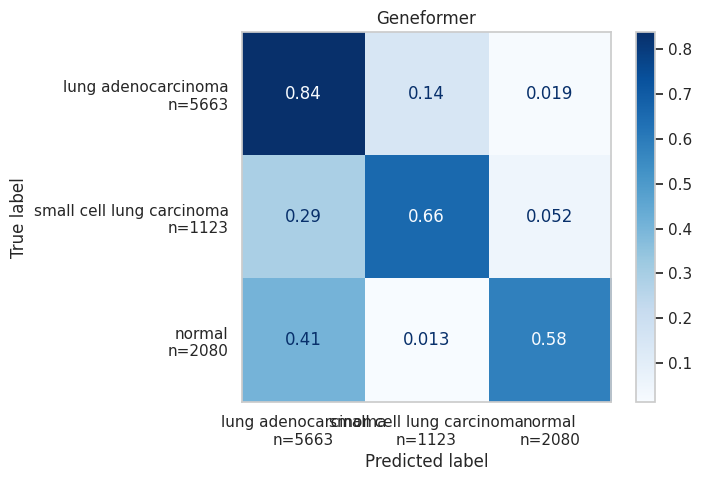

In [41]:
cc.plot_conf_mat(
    conf_mat_dict={"Geneformer": all_metrics_test["conf_matrix"]},
    output_directory="finetuned_modelT",
    output_prefix="lung_classifier",
    custom_class_order=["lung adenocarcinoma", "small cell lung carcinoma", "normal"]
)

## 27. Plot prediction distributions

This visualizes predicted probabilities/classes for the disease classifier and helps identify which disease states overlap in model space.

<Figure size 1500x1500 with 0 Axes>

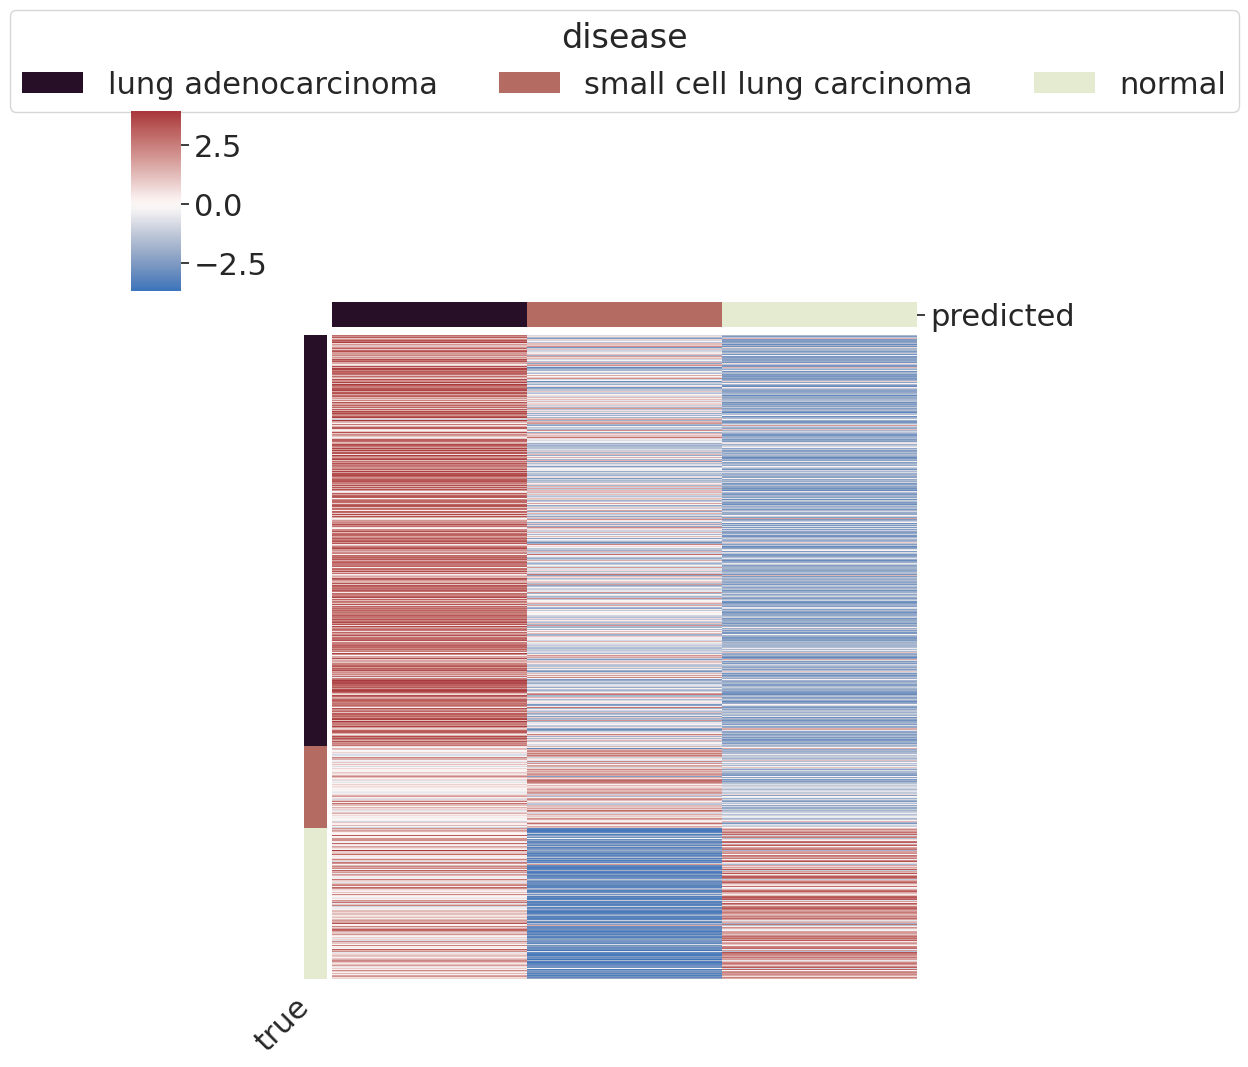

In [42]:
cc.plot_predictions(
    predictions_file="finetuned_modelT/lung_classifier_pred_dict.pkl",
    id_class_dict_file="finetuned_modelT/lung_classifier_id_class_dict.pkl",
    title="disease",
    output_directory="finetuned_modelT",
    output_prefix="lung_classifierT",
    custom_class_order=["lung adenocarcinoma", "small cell lung carcinoma", "normal"]
)

# Embedding analysis

The fine-tuned classifier is used to extract latent T-cell embeddings for visualization and downstream perturbation.

# Get embedding

## 28. Extract Geneformer embeddings

Embeddings summarize each T cell in the fine-tuned model's latent space. These embeddings are expected to encode disease-associated immune programs.

In [46]:
from geneformer import EmbExtractor
embex = EmbExtractor(
    model_type="CellClassifier",
    num_classes=3,
    filter_data=None,
    max_ncells=None,
    emb_layer=-1,
    emb_label=["disease", "individual"],
    labels_to_plot=["disease", "individual"],
    forward_batch_size=256,
    nproc=4,
    model_version="V1",
)

embs = embex.extract_embs(
    model_directory="finetuned_modelT/260612_geneformer_cellClassifier_lung_classifier/ksplit1/",
    input_data_file="output_dataT/tokenized.dataset",
    output_directory="embed_dataT",
    output_prefix="finetuned_embs"
)

print(type(embs))
try:
    print(embs.shape)
except Exception:
    pass

model_version selected as V1 so changing emb_mode from 'cls' to 'cell' as V1 models do not have a <cls> token.
100%|█████████████████████████████████████████| 133/133 [01:33<00:00,  1.43it/s]


<class 'pandas.core.frame.DataFrame'>
(33988, 258)


## 29. Visualize embeddings

UMAP and heatmap plots assess whether Geneformer embeddings separate normal, LUAD, and SCLC T-cell states.

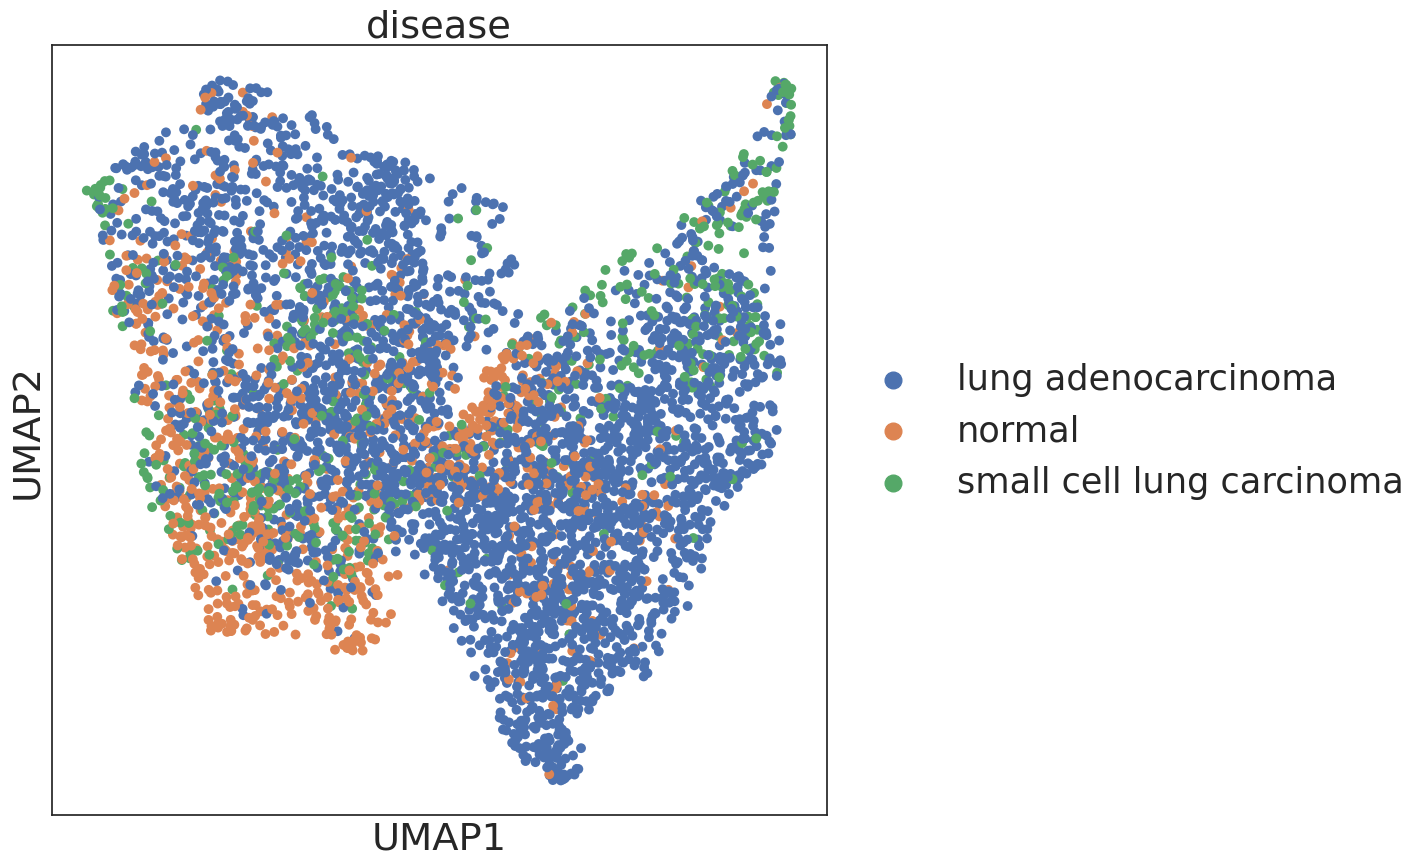

<Figure size 1000x1000 with 0 Axes>

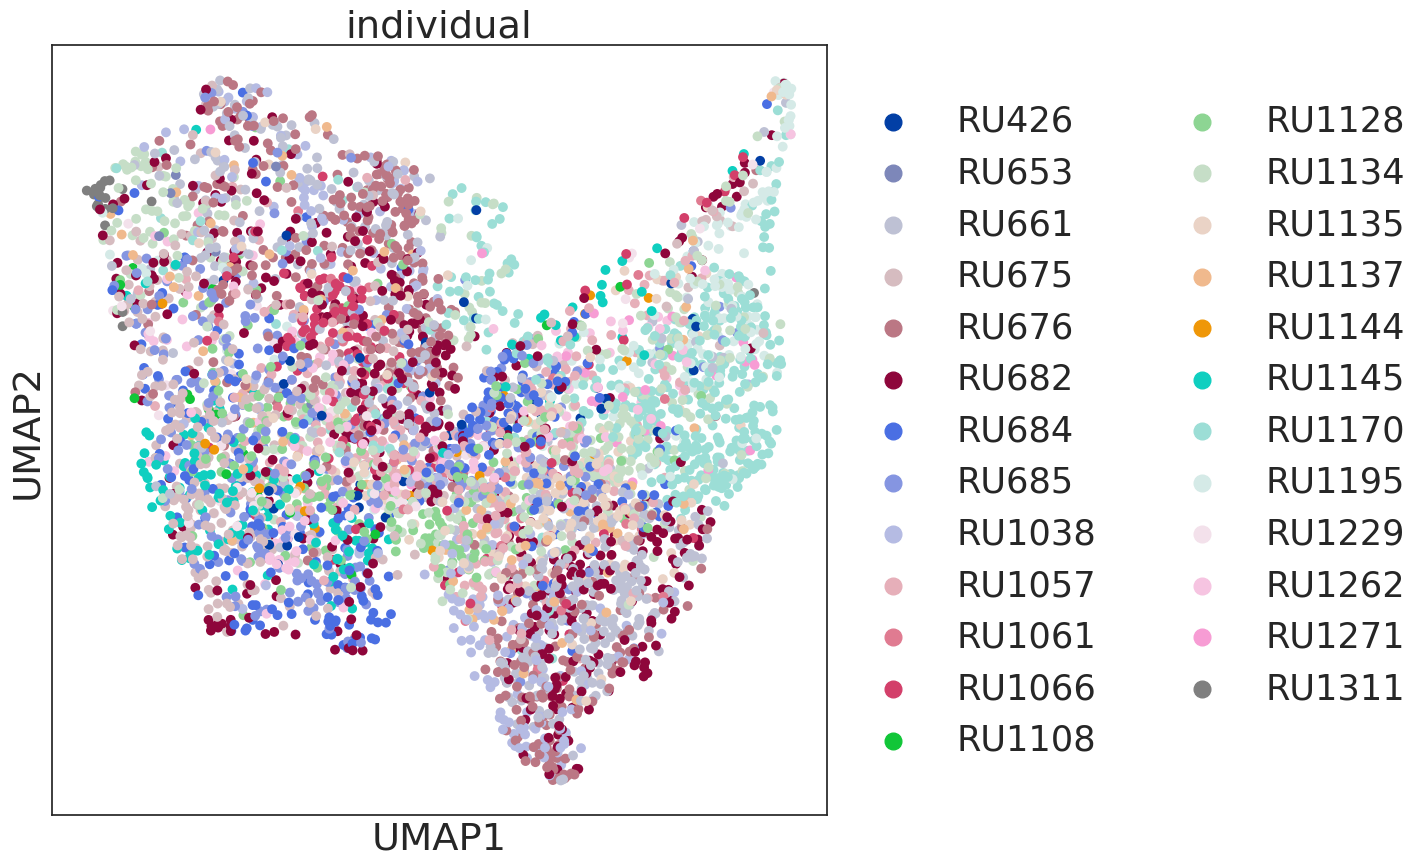

/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1000x1000 with 0 Axes>

<Figure size 2250x2250 with 0 Axes>

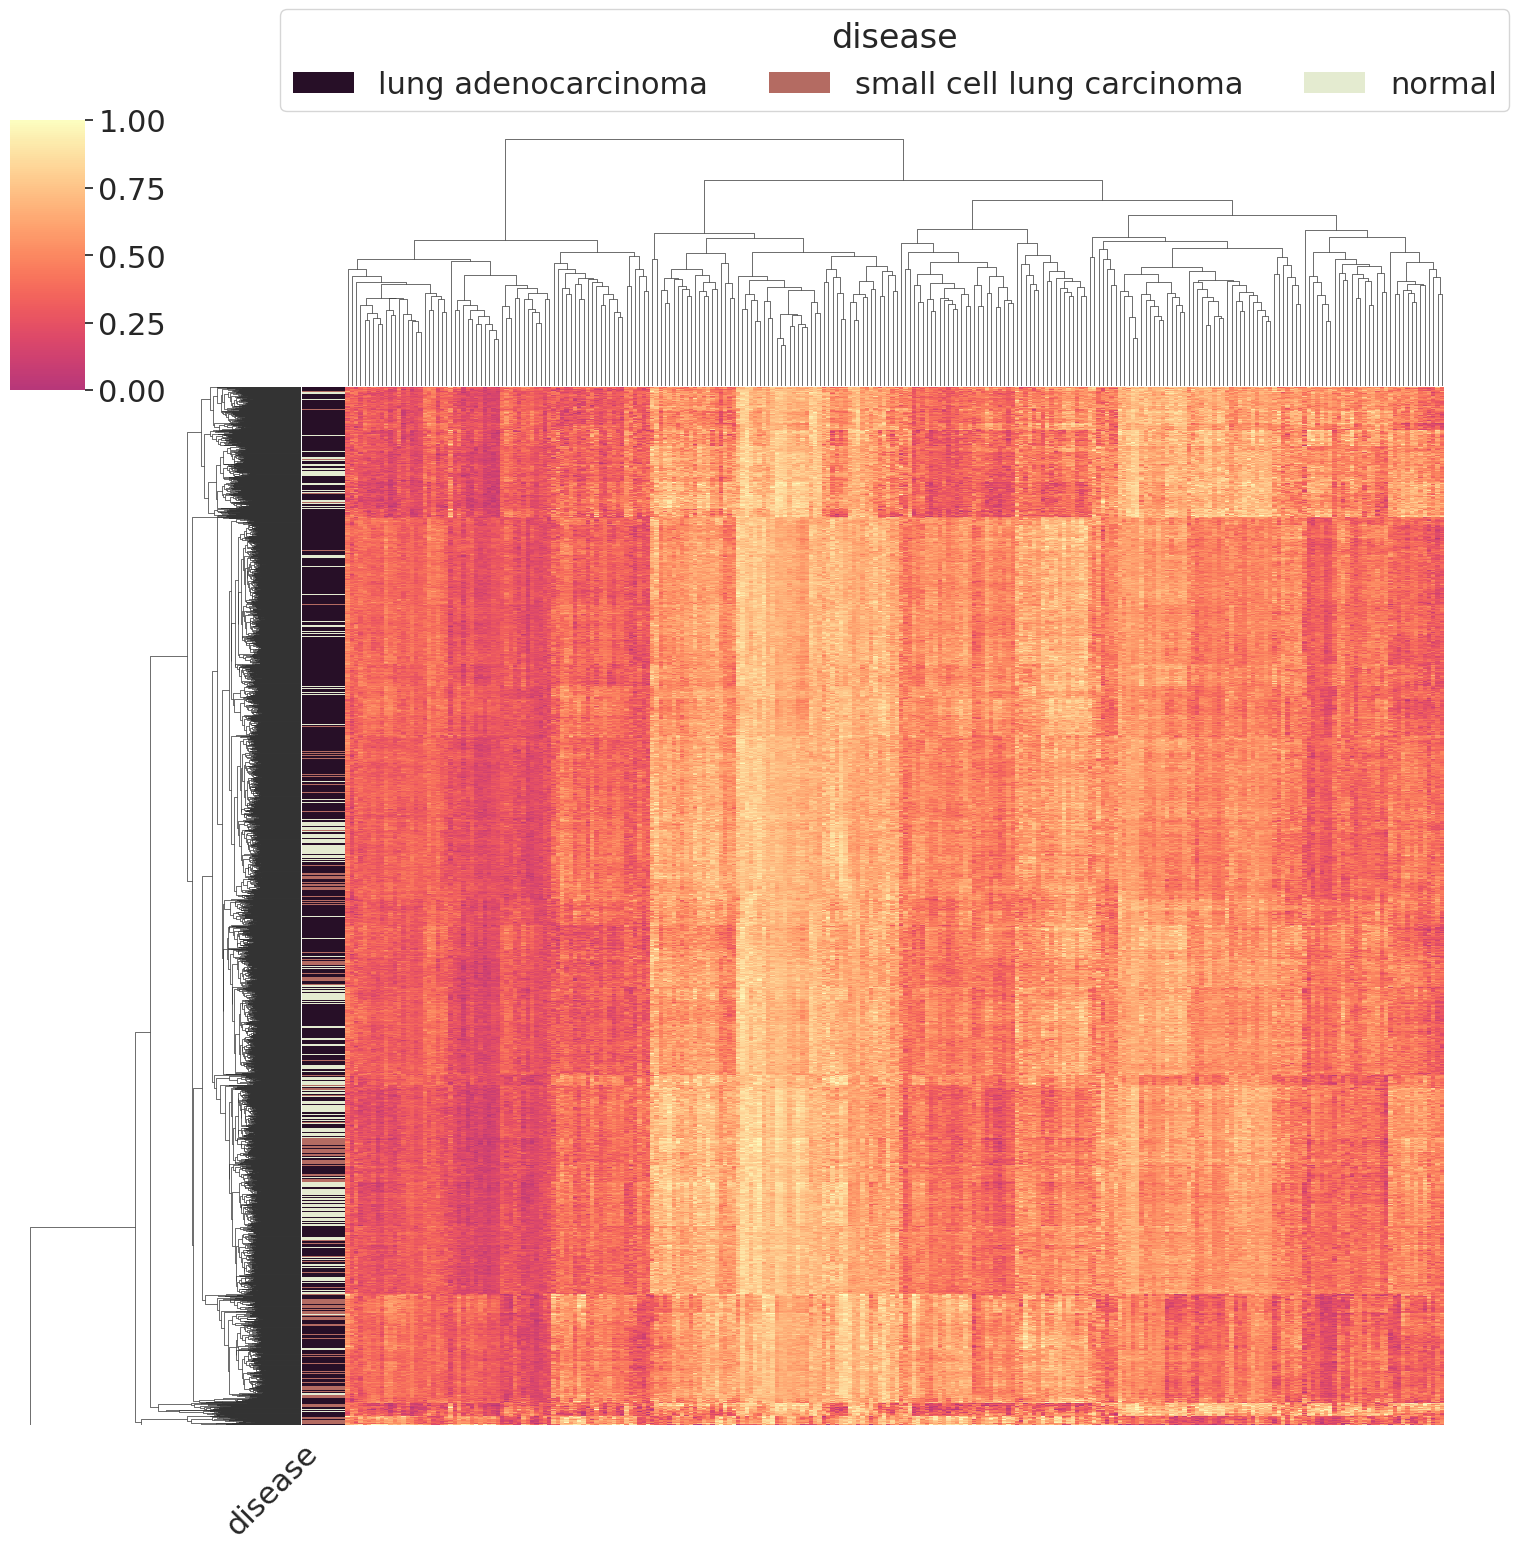

/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1000x1000 with 0 Axes>

<Figure size 2250x2250 with 0 Axes>

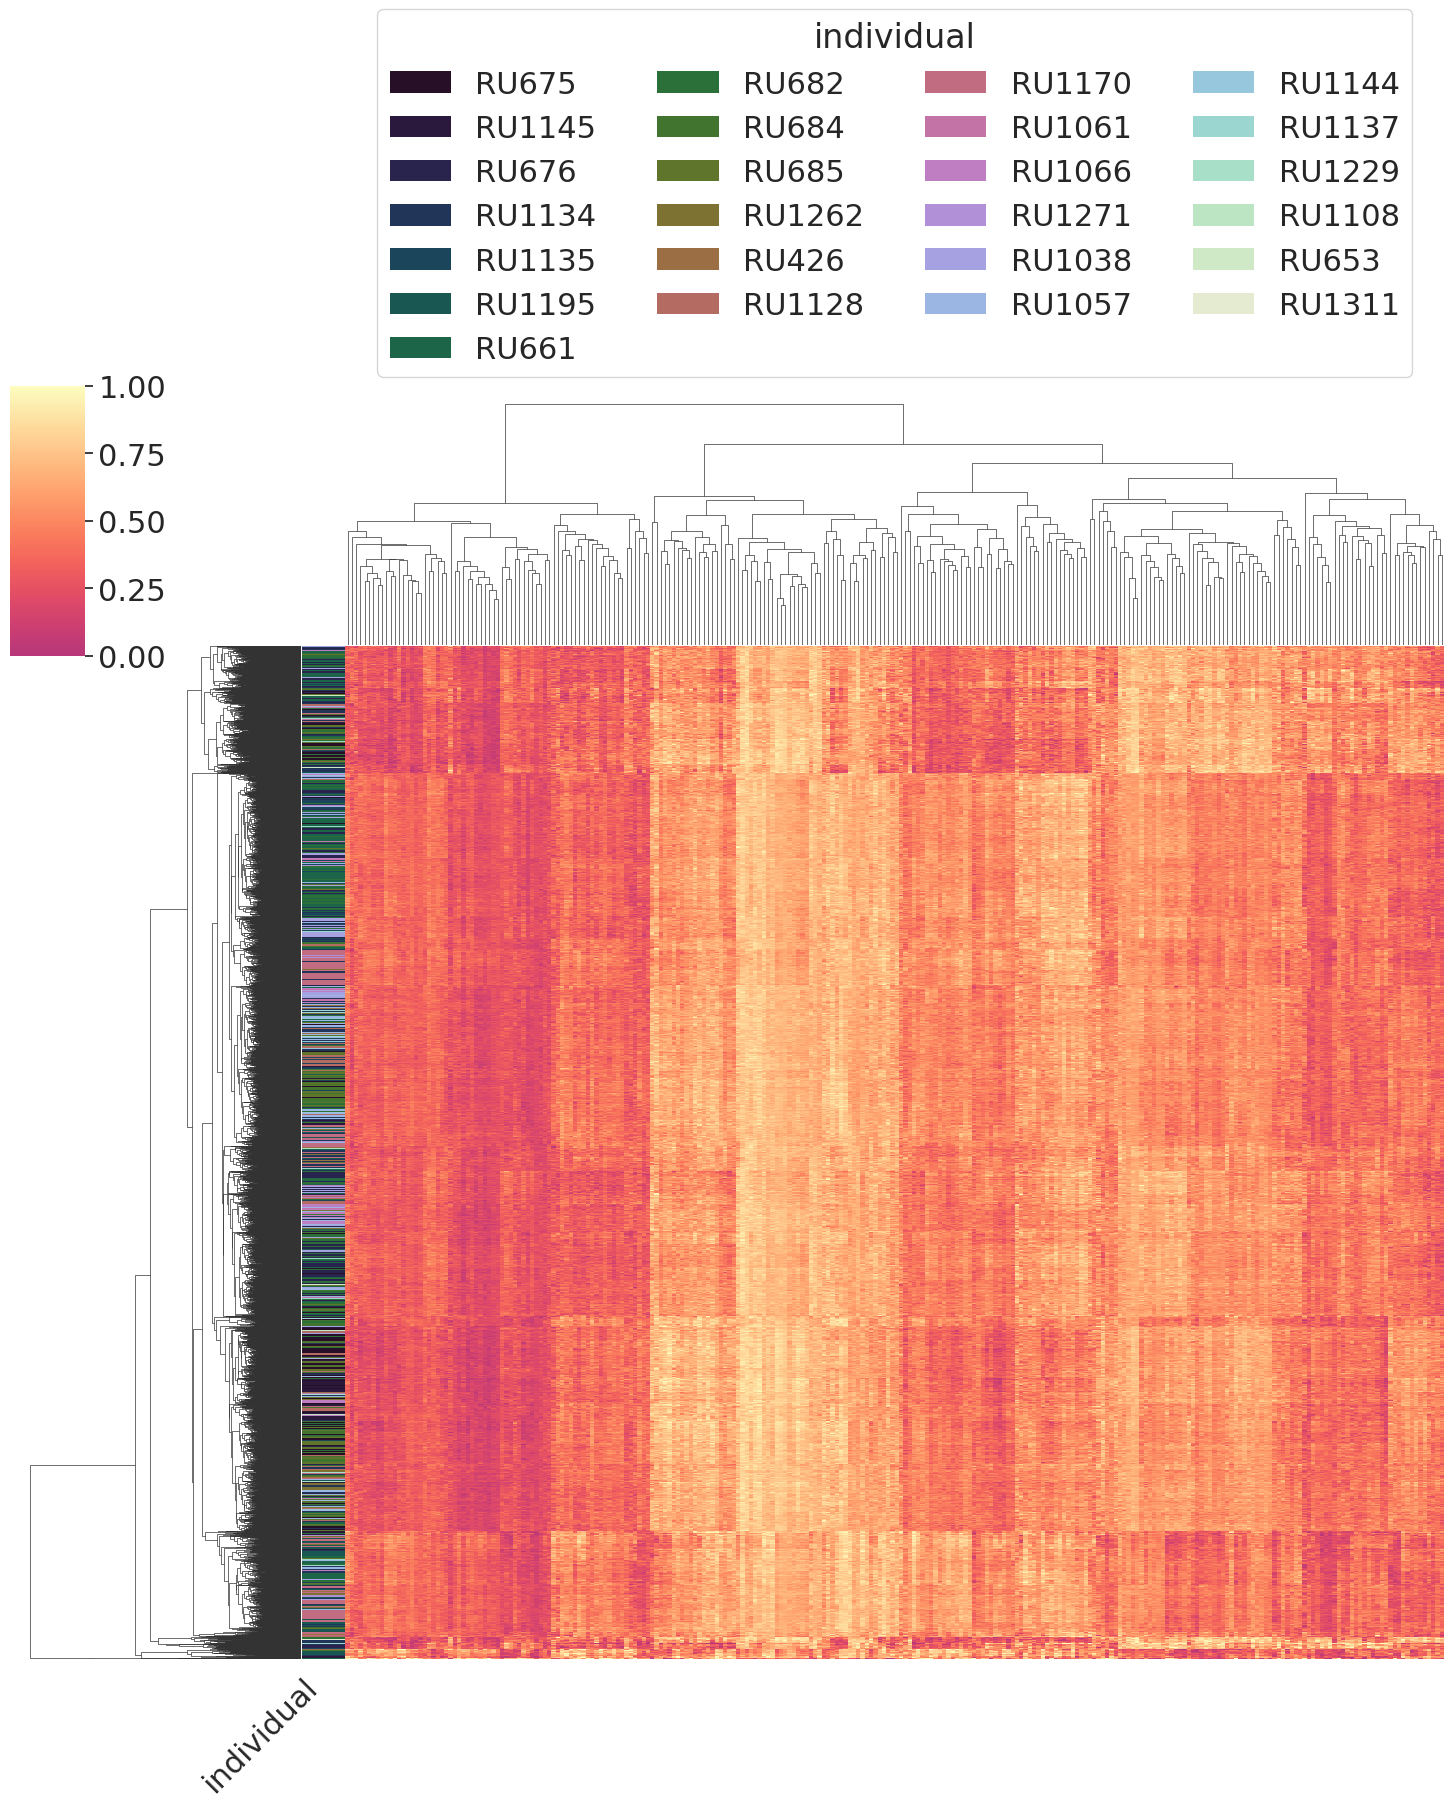

<Figure size 1000x1000 with 0 Axes>

In [47]:
embex.plot_embs(
    embs=embs,
    plot_style="umap",
    output_directory="embed_dataT",
    output_prefix="emb_umap",
    max_ncells_to_plot=5000,
)

embex.plot_embs(
    embs=embs,
    plot_style="heatmap",
    output_directory="embed_dataT",
    output_prefix="emb_heatmap",
    max_ncells_to_plot=5000,
)

# In silico perturbation

Geneformer perturbation estimates how deleting each gene changes the disease-state embedding of T cells.

# pertubation

## 30. Define disease-state transition for perturbation

This run models a LUAD-to-normal transition, using SCLC as the alternate disease state. This is biologically useful, but for an SCLC-focused project the next run should model SCLC-to-normal with LUAD as the alternate state.

In [48]:
cell_states_to_model = {
    "state_key": "disease",
    "start_state": "lung adenocarcinoma",
    "goal_state": "normal",
    "alt_states": ["small cell lung carcinoma"],
}

embex = EmbExtractor(
    model_type="CellClassifier",
    num_classes=3,
    filter_data=None,
    max_ncells=5000,
    emb_layer=-1,
    summary_stat="exact_mean",
    # emb_label=["disease", "individual"],
    # labels_to_plot=["disease", "individual"],
    forward_batch_size=256,
    nproc=4,
    model_version="V1",
)

state_embs_dict = embex.get_state_embs(
    cell_states_to_model,
    model_directory="finetuned_modelT/260612_geneformer_cellClassifier_lung_classifier/ksplit1/",
    input_data_file="output_dataT/tokenized.dataset",
    output_directory="embed_dataT",
    output_prefix="state_embs",
)

state_embs_dict.keys()

model_version selected as V1 so changing emb_mode from 'cls' to 'cell' as V1 models do not have a <cls> token.
100%|███████████████████████████████████████████| 16/16 [00:13<00:00,  1.19it/s]


dict_keys(['lung adenocarcinoma', 'normal', 'small cell lung carcinoma'])

## 31. Run all-gene deletion perturbation

Each detected gene is computationally deleted, and Geneformer estimates whether this moves T-cell states toward the goal state or alternate state. This is hypothesis-generating, not experimental proof.

In [ ]:
from geneformer import InSilicoPerturber

perturbation_type = "delete"
genes_to_perturb = "all"

isp = InSilicoPerturber(
    perturb_type=perturbation_type,
    genes_to_perturb=genes_to_perturb,
    model_type="CellClassifier",
    num_classes=3,
    emb_mode="cell",
    cell_states_to_model=cell_states_to_model,
    state_embs_dict=state_embs_dict,
    max_ncells=2000,
    emb_layer=-1,
    forward_batch_size=256,
    nproc=4,
    model_version="V1",
)

isp.perturb_data(
    model_directory="finetuned_modelT/260612_geneformer_cellClassifier_lung_classifier/ksplit1/",
    input_data_file="output_dataT/tokenized.dataset",
    output_directory="pert_deleteT",
    output_prefix="luad2normal",
)

## 32. Compute perturbation statistics

Genes are ranked by their ability to shift LUAD T-cell embeddings toward normal and relative to SCLC. FDR correction and detection count filters are used to prioritize more reliable hits.

In [52]:
from geneformer import InSilicoPerturberStats
ispstats = InSilicoPerturberStats(
    mode="goal_state_shift",
    genes_perturbed="all",
    combos=0,
    anchor_gene=None,
    cell_states_to_model=cell_states_to_model,
    model_version="V1",
)

ispstats.get_stats(
    input_data_directory="pert_deleteT",
    null_dist_data_directory=None,
    output_directory="pert_resultT",
    output_prefix="lung_Tcell_gene_delete_pert_result",
)

  0%|                                                                                                               | 0/13937 [00:00<?, ?it/s]/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/in_silico_perturber_stats.py:436: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cos_sims_full_df = pd.concat([cos_sims_full_df, cos_sims_df_i])
100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 13937/13937 [06:44<00:00, 34.48it/s]


## 33. Load perturbation results

The result table contains effect sizes, FDR values, detection counts, and gene names for all tested genes.

In [53]:
results = pd.read_csv("pert_resultT/lung_Tcell_gene_delete_pert_result.csv", index_col=0)
results

,Gene,Gene_name,Ensembl_ID,Shift_to_goal_end,Shift_to_alt_end_small cell lung carcinoma,Goal_end_vs_random_pval,Alt_end_vs_random_pval_small cell lung carcinoma,Goal_end_FDR,Alt_end_FDR_small cell lung carcinoma,N_Detections,Sig
12802,17539,NAP1L6P,ENSG00000204118,0.002151,0.001737,4.173071e-08,3.387431e-07,2.823305e-06,0.000023,21,1
5582,6873,HRH4,ENSG00000134489,0.001235,0.001180,2.045086e-03,1.219677e-03,3.231560e-02,0.025834,4,1
10188,13091,ZNF556,ENSG00000172000,0.000887,0.000764,4.155008e-04,7.651842e-04,9.446712e-03,0.018324,9,1
3046,3662,IL2,ENSG00000109471,0.000730,0.000476,2.463227e-13,2.609888e-05,3.038053e-11,0.001123,51,1
3740,4508,KISS1R,ENSG00000116014,0.000704,0.000663,5.566129e-04,6.886171e-03,1.206456e-02,0.090711,11,1
...,...,...,...,...,...,...,...,...,...,...,...
5629,6935,CLDN10,ENSG00000134873,-0.003500,-0.003536,8.392342e-02,8.376837e-02,3.631297e-01,0.412341,1,0
10515,13585,MFSD4A,ENSG00000174514,-0.004218,-0.004351,8.357643e-02,8.355787e-02,3.626263e-01,0.412267,1,0
5866,7223,NKX2-8,ENSG00000136327,-0.004550,-0.004453,8.345897e-02,8.352695e-02,3.624704e-01,0.412267,1,0
6522,8068,ADCYAP1,ENSG00000141433,-0.004663,-0.004973,8.343425e-02,8.339720e-02,3.624704e-01,0.412267,1,0


## 34. Volcano-like perturbation plot

This plot shows genes by effect size and significance. It helps identify candidate regulators whose deletion shifts T-cell state toward normal.

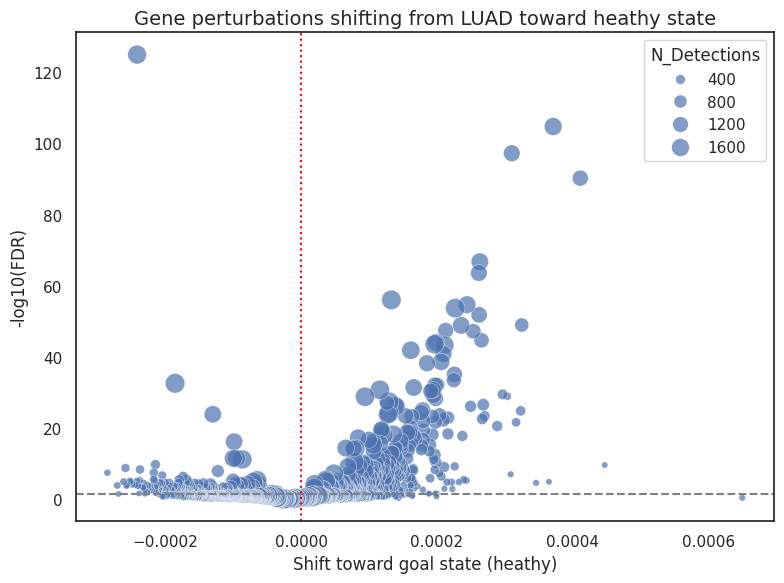

In [57]:
df = results.copy()
df = df[df["N_Detections"] > 100]
df["minus_log10_fdr"] = -np.log10(df["Goal_end_FDR"])

plt.figure(figsize=(8,6))
sns.set_theme(style="white")

sns.scatterplot(data=df,
                x="Shift_to_goal_end", y="minus_log10_fdr", size="N_Detections",
                sizes=(20,200), alpha=0.7
               )
plt.axvline(0, color="red", linestyle=":")
plt.axhline(-np.log10(0.05), color="gray", linestyle="--")

plt.title("Gene perturbations shifting from LUAD toward heathy state", fontsize=14)
plt.xlabel("Shift toward goal state (heathy)", fontsize=12)
plt.ylabel("-log10(FDR)", fontsize=12)

plt.tight_layout()
plt.show()

## 35. Top genes shifting toward normal

After filtering by FDR and detection count, top positive hits include genes such as CCR4, HSPH1, and DNAJB1. These should be interpreted as computational candidates requiring validation.

        Gene Gene_name       Ensembl_ID  Shift_to_goal_end  \
11469  15208      CCR4  ENSG00000183813           0.000447   
4180    5069     HSPH1  ENSG00000120694           0.000411   
5276    6489    DNAJB1  ENSG00000132002           0.000371   
13865  24339       NaN  ENSG00000275993           0.000365   
13644  21019     ZBED6  ENSG00000257315           0.000346   
...      ...       ...              ...                ...   
7313    9131   HIKESHI  ENSG00000149196          -0.000258   
6846    8471     TPRKB  ENSG00000144034          -0.000261   
1548    1842     CDIP1  ENSG00000089486          -0.000269   
4441    5394       NMI  ENSG00000123609          -0.000270   
9628   12268     ATG4B  ENSG00000168397          -0.000285   

       Shift_to_alt_end_small cell lung carcinoma  Goal_end_vs_random_pval  \
11469                                    0.000350             2.446722e-12   
4180                                     0.000252             1.685966e-94   
5276                 

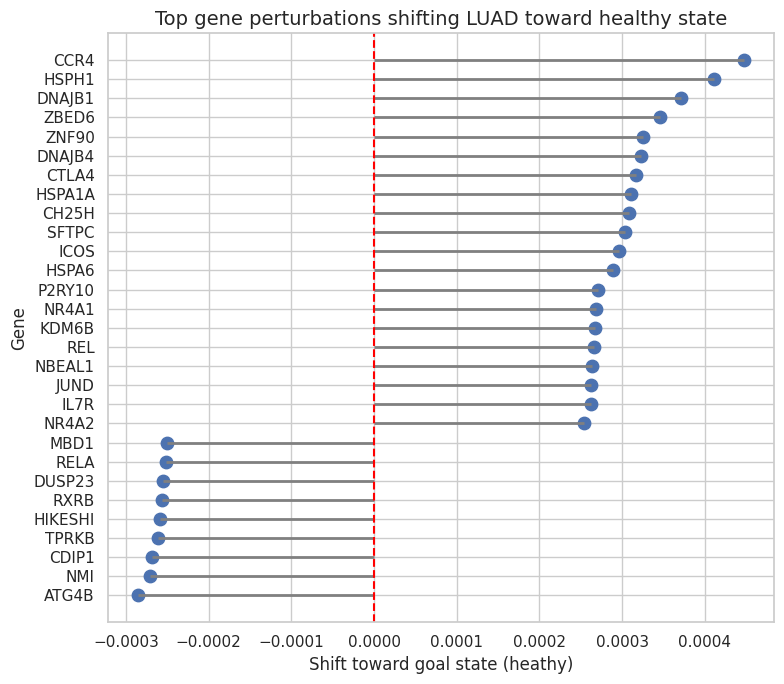

In [60]:
df = results.copy()
df = df[df["Goal_end_FDR"] < 0.05]
df = df[df["N_Detections"] > 100]
print(df)

n_top_genes = 30
df_plot = (
    df.reindex(
        df["Shift_to_goal_end"]
        .abs()
        .sort_values(ascending=False)
        .index
    )
    .head(n_top_genes)
    .sort_values("Shift_to_goal_end")
)
df_plot = df_plot.dropna(subset=["Gene_name"])

plt.figure(figsize=(8, 7))
sns.set_theme(style="whitegrid")

plt.scatter(df_plot["Shift_to_goal_end"],
            df_plot["Gene_name"],
            s=80
           )
plt.hlines(y=df_plot["Gene_name"], xmin=0, xmax=df_plot["Shift_to_goal_end"], color="gray", linewidth=2)
plt.axvline(x=0, color="red", linestyle="--", linewidth=1.5)

plt.title("Top gene perturbations shifting LUAD toward healthy state", fontsize=14)
plt.xlabel("Shift toward goal state (heathy)", fontsize=12)
plt.ylabel("Gene", fontsize=12)

plt.tight_layout()
plt.show()

## 36. Top genes significant relative to the SCLC alternate state

This identifies genes whose deletion significantly affects the relationship to the alternate SCLC state. Hits overlapping with the goal-state list may represent broader cancer-associated T-cell regulators.

        Gene Gene_name       Ensembl_ID  Shift_to_goal_end  \
11469  15208      CCR4  ENSG00000183813           0.000447   
4180    5069     HSPH1  ENSG00000120694           0.000411   
5276    6489    DNAJB1  ENSG00000132002           0.000371   
13865  24339       NaN  ENSG00000275993           0.000365   
13644  21019     ZBED6  ENSG00000257315           0.000346   
...      ...       ...              ...                ...   
7348    9180      EI24  ENSG00000149547          -0.000163   
7240    9030      CIZ1  ENSG00000148337          -0.000168   
4050    4891    NDUFA8  ENSG00000119421          -0.000175   
8353   10523      YDJC  ENSG00000161179          -0.000183   
2311    2760   HCFC1R1  ENSG00000103145          -0.000204   

       Shift_to_alt_end_small cell lung carcinoma  Goal_end_vs_random_pval  \
11469                                    0.000350             2.446722e-12   
4180                                     0.000252             1.685966e-94   
5276                 

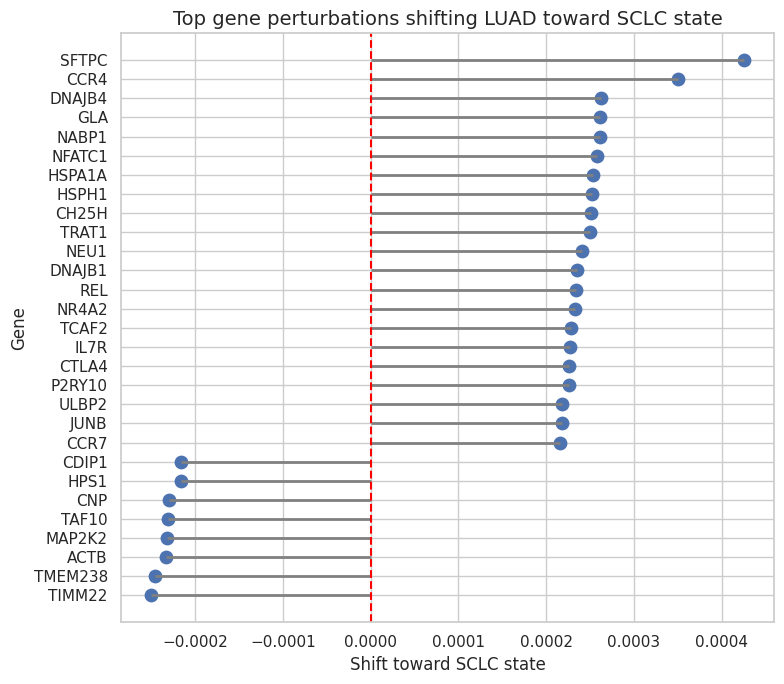

In [62]:
df = results.copy()
df = df[df["Alt_end_FDR_small cell lung carcinoma"] < 0.05]
df = df[df["N_Detections"] > 100]
print(df)

n_top_genes = 30
df_plot = (
    df.reindex(
        df["Shift_to_alt_end_small cell lung carcinoma"]
        .abs()
        .sort_values(ascending=False)
        .index
    )
    .head(n_top_genes)
    .sort_values("Shift_to_alt_end_small cell lung carcinoma")
)
df_plot = df_plot.dropna(subset=["Gene_name"])

plt.figure(figsize=(8, 7))
sns.set_theme(style="whitegrid")

plt.scatter(df_plot["Shift_to_alt_end_small cell lung carcinoma"],
            df_plot["Gene_name"],
            s=80
           )
plt.hlines(y=df_plot["Gene_name"], xmin=0, xmax=df_plot["Shift_to_alt_end_small cell lung carcinoma"], color="gray", linewidth=2)
plt.axvline(x=0, color="red", linestyle="--", linewidth=1.5)

plt.title("Top gene perturbations shifting LUAD toward SCLC state", fontsize=14)
plt.xlabel("Shift toward SCLC state", fontsize=12)
plt.ylabel("Gene", fontsize=12)

plt.tight_layout()
plt.show()

# Final interpretation and recommended next steps

This notebook demonstrates a feasible Geneformer workflow for disease classification and perturbation analysis in lung T cells. The key biological result is that T-cell transcriptomes contain disease-associated signal, but the current analysis is limited by donor imbalance and possible donor leakage in the train/eval split. The most important next technical improvement is to enforce unique donor IDs across train/eval/test and rerun using a run-specific output structure. The most important biological next step is to rerun perturbation as SCLC → normal with LUAD as the alternate state.


# Part II: Epithelial Analysis


# Commented Geneformer Epithelial Analysis

This notebook has been annotated for medical and translational collaborators.  
The workflow evaluates whether Geneformer can distinguish lung adenocarcinoma (LUAD) epithelial cells from small cell lung carcinoma (SCLC) epithelial cells, and then uses in silico perturbation to explore genes that may shift LUAD epithelial states toward an SCLC-like state.

**High-level interpretation:** epithelial tumor cells carry a much stronger tumor-lineage signal than T cells. The epithelial classifier performs strongly, while T-cell classification shows more overlap between cancer-associated immune states.

# Explore adata

## 1. Import libraries

This cell imports standard analysis tools for single-cell RNA-seq, visualization, and Geneformer analysis. The notebook uses Scanpy for AnnData handling and Geneformer for tokenization, classifier fine-tuning, embeddings, and perturbation.

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import os

## 2. Load the full lung cancer single-cell dataset

The starting AnnData object contains all available cells and genes from the lung cancer dataset. Later cells restrict the analysis to lung-derived epithelial cells, which are the tumor-cell compartment most relevant for LUAD-vs-SCLC lineage classification.

In [2]:
adata = sc.read_h5ad("../sclc_raw/5b7cbce2-ed53-47a4-99f8-10af741814e6.h5ad")
adata

AnnData object with n_obs × n_vars = 147137 × 22021
    obs: 'ngenes', 'libsize', 'mito_frac', 'RBP_frac', 'batch', 'donor_id', 'treatment', 'procedure', 'histo', 'cell_type_coarse', 'cell_type_fine', 'cell_type_general', 'clusters', 'cell_type_med', 'H_knn', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'HTAN_Biospecimen_ID', 'HTAN_Participant_ID', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_umap'

## 3. Inspect cell metadata

This checks the available clinical/sample/cell annotations. These metadata determine which columns can be used for disease labels, donor-level train/test splitting, tissue filtering, sex/age balancing, and cell-type filtering.

In [3]:
# Explore cell metadata
print("Columns:", adata.obs.columns.tolist())
display(adata.obs.head())
print("Metadata summary:")
display(adata.obs.describe(include="all"))

# Explore unique values of categorical metadata
categorical_cols = [
    col for col in adata.obs.columns
    if adata.obs[col].dtype == "object"
    or str(adata.obs[col].dtype).startswith("category")
    ]
for col in categorical_cols:
    try:
        print(adata.obs[col].value_counts().head(20))
    except:
        print("Cannot display value counts")

display(pd.crosstab(adata.obs["disease"],adata.obs["cell_type"]))

Columns: ['ngenes', 'libsize', 'mito_frac', 'RBP_frac', 'batch', 'donor_id', 'treatment', 'procedure', 'histo', 'cell_type_coarse', 'cell_type_fine', 'cell_type_general', 'clusters', 'cell_type_med', 'H_knn', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'HTAN_Biospecimen_ID', 'HTAN_Participant_ID', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']


,ngenes,libsize,mito_frac,RBP_frac,batch,donor_id,treatment,procedure,histo,cell_type_coarse,...,HTAN_Participant_ID,tissue_type,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
Cell,,,,,,,,,,,,,,,,,,,,,
RU1311A_T_1_165945547864806,255,2.594393,0.055980,0.315522,RU1311A_T_1,RU1311,Platinum Doublet,Biopsy,SCLC,Lymphoid,...,HTA8_2016,tissue,T cell,10x 3' v3,small cell lung carcinoma,female,lung,unknown,77-year-old stage,q1?ma!F=Xe
RU1215_192110488599350,3720,4.285895,0.060109,0.401657,RU1215,RU1215,Naive,Thoracentesis,SCLC,Epithelial,...,HTA8_2012,tissue,epithelial cell,10x 3' v3,small cell lung carcinoma,female,pleural effusion,unknown,75-year-old stage,M!tK?#Xfph
RU1057_T_231270811326245,2293,3.963505,0.030455,0.363389,RU1057_T,RU1057,Naive,Resection,LUAD,Mesenchymal,...,HTA8_1002,tissue,endothelial cell,10x 3' v2,lung adenocarcinoma,female,lung,unknown,67-year-old stage,wUE_o#x^2C
RU1152_130751366121844,5093,4.374162,0.073601,0.185821,RU1152,RU1152,Naive,Biopsy,SCLC,Epithelial,...,HTA8_2009,tissue,epithelial cell,10x 3' v3,small cell lung carcinoma,male,lymph node,unknown,71-year-old stage,!9F#zgnv3I
RU699_227364270922139,1658,3.729489,0.011559,0.218121,RU699,RU699,"Platinum Doublet,Immunotherapy",Resection,LUAD,Lymphoid,...,HTA8_1021,tissue,T cell,10x 3' v2,lung adenocarcinoma,female,adrenal gland,unknown,44-year-old stage,l6CxDWQf>R


Metadata summary:


,ngenes,libsize,mito_frac,RBP_frac,batch,donor_id,treatment,procedure,histo,cell_type_coarse,...,HTAN_Participant_ID,tissue_type,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
count,147137.000000,147137.000000,147137.000000,147137.000000,147137,147137,147137,147137,147137,147137,...,147137,147137,147137,147137,147137,147137,147137,147137,147137,147137
unique,NaN,NaN,NaN,NaN,52,42,9,3,3,4,...,45,1,11,3,3,2,8,3,26,147137
top,NaN,NaN,NaN,NaN,RU1293A,RU1108,Naive,Resection,SCLC,Epithelial,...,HTA8_2005,tissue,epithelial cell,10x 3' v2,small cell lung carcinoma,female,lung,unknown,74-year-old stage,q1?ma!F=Xe
freq,NaN,NaN,NaN,NaN,6484,11294,66888,86272,77143,64301,...,11294,147137,64302,92035,77143,83259,90384,134630,19763,1
mean,2205.696840,3.721064,0.060367,0.245877,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1580.897688,0.508769,0.043701,0.112980,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,36.000000,2.004321,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1011.000000,3.469380,0.026598,0.163331,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1680.000000,3.752356,0.049331,0.229660,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3284.000000,4.094611,0.086054,0.319175,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


batch
RU1293A                     6484
RU1231A                     5098
RU1145                      4696
RU661_T                     4434
RU1215                      4420
RU1108a_Bambanker_Frozen    4231
RU1108a_RPMI                4137
RU1065C                     4060
RU682_T                     3931
RU676                       3900
RU1262C                     3857
RU682_N                     3829
RU1229A_Frozen              3811
RU1080C                     3799
RU1066                      3794
RU1134-CN2                  3300
RU1322A_LN                  3275
RU1134_Sort-Freeze          3264
RU1138                      3209
RU675_T                     3196
Name: count, dtype: int64
donor_id
RU1108    11294
RU682      7760
RU1134     6564
RU1293     6484
RU675      6175
RU1170     5679
RU1231     5098
RU1181     4873
RU1145     4696
RU1144     4603
RU661      4434
RU1215     4420
RU1065     4060
RU676      3900
RU1262     3857
RU1229     3811
RU1080     3799
RU1066     3794
RU1322     

cell_type,fibroblast,epithelial cell,T cell,mast cell,endothelial cell,erythrocyte,macrophage,B cell,dendritic cell,neutrophil,plasma cell
disease,,,,,,,,,,,
lung adenocarcinoma,4067,7575,29580,971,2395,46,4866,4846,2346,358,629
small cell lung carcinoma,800,55876,15638,105,593,1,1051,788,1530,726,35
normal,37,851,6630,191,90,0,3334,127,1032,21,2


## 4. Inspect gene metadata

Geneformer requires Ensembl gene identifiers. This cell checks whether gene-level metadata contain the expected identifiers and gene annotations.

In [4]:
# Explore gene metadata
print("Columns:", adata.var.columns.tolist())
display(adata.var.head())
print("Metadata summary:")
display(adata.var.describe(include="all"))

Columns: ['feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type']


,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000121410,False,A1BG,NCBITaxon:9606,gene,2301,protein_coding
ENSG00000148584,False,A1CF,NCBITaxon:9606,gene,2211,protein_coding
ENSG00000175899,False,A2M,NCBITaxon:9606,gene,590,protein_coding
ENSG00000166535,False,A2ML1,NCBITaxon:9606,gene,592,protein_coding
ENSG00000128274,False,A4GALT,NCBITaxon:9606,gene,1956,protein_coding


Metadata summary:


,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
count,22021,22021,22021,22021,22021,22021
unique,1,22017,1,1,4672,17
top,False,LINC03021,NCBITaxon:9606,gene,582,protein_coding
freq,22021,2,22021,22021,45,17494


In [6]:
# Explore one cell
cell_id = adata.obs_names[0]
print("Cell ID:", cell_id)
display(adata.obs.loc[cell_id])

expr = adata[cell_id].X
expr = np.array(expr).flatten()
top_idx = np.argsort(expr)[::-1][:20]
top_genes = pd.DataFrame({
    "gene": adata.var_names[top_idx],
    "expression": expr[top_idx]
})
display(top_genes)

Cell ID: RU1311A_T_1_165945547864806


ngenes                                                            255
libsize                                                      2.594393
mito_frac                                                     0.05598
RBP_frac                                                     0.315522
batch                                                     RU1311A_T_1
donor_id                                                       RU1311
treatment                                            Platinum Doublet
procedure                                                      Biopsy
histo                                                            SCLC
cell_type_coarse                                             Lymphoid
cell_type_fine                                                 T cell
cell_type_general                                              Immune
clusters                                                           23
cell_type_med                                                  T cell
H_knn               

,gene,expression
0,ENSG00000121410,<Compressed Sparse Row sparse matrix of dtype ...


## 5. Optimize AnnData for Geneformer

Large AnnData objects often contain embeddings, graphs, and unneeded metadata. Removing unused objects reduces file size and makes tokenization faster and more stable.

# Optimize adata

In [7]:
adata.obsm = {}
adata.uns = {}
adata

AnnData object with n_obs × n_vars = 147137 × 22021
    obs: 'ngenes', 'libsize', 'mito_frac', 'RBP_frac', 'batch', 'donor_id', 'treatment', 'procedure', 'histo', 'cell_type_coarse', 'cell_type_fine', 'cell_type_general', 'clusters', 'cell_type_med', 'H_knn', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'HTAN_Biospecimen_ID', 'HTAN_Participant_ID', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'

## 6. Keep essential metadata

This step retains only the metadata required for classification and interpretation: donor ID, disease, cell type, sex, age/development stage, and tissue. This reduces memory and simplifies reproducibility.

In [9]:
keep_obs = ["donor_id", "cell_type", "disease", "sex", "development_stage", "tissue"]
adata.obs = adata.obs[keep_obs].copy()
keep_var = ["feature_name"]
adata.var = adata.var[keep_var].copy()

adata.var["ensembl_id"] = adata.var.index.astype(str)
adata.obs["cell_id"] = adata.obs_names
if "n_counts" not in adata.obs.columns:
    adata.obs["n_counts"] = np.asarray(adata.X.sum(axis=1)).ravel()

adata

AnnData object with n_obs × n_vars = 147137 × 22021
    obs: 'donor_id', 'cell_type', 'disease', 'sex', 'development_stage', 'tissue', 'cell_id', 'n_counts'
    var: 'feature_name', 'ensembl_id'

## 7. Convert development stage to numeric age

The dataset stores age as strings such as `77-year-old stage`. Geneformer balancing functions need clean metadata, so the numeric age is extracted here.

In [ ]:
adata.obs["age"] = (
    adata.obs["development_stage"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

adata.obs["age"] = adata.obs["age"].fillna(
    adata.obs["age"].median()
)

In [16]:
print(adata.obs["donor_id"].unique())
print(adata.obs["tissue"].unique())
print(adata.obs["cell_type"].unique())
print(adata.obs["disease"].unique())
print(adata.obs["sex"].unique())
print(adata.obs["age"].unique())

['RU1311', 'RU1215', 'RU1057', 'RU1152', 'RU699', ..., 'RU1195', 'RU1061', 'RU426', 'RU1271', 'RU653']
Length: 42
Categories (42, object): ['PleuralEffusion', 'RU255', 'RU426', 'RU653', ..., 'RU1271', 'RU1293', 'RU1311', 'RU1322']
['lung', 'pleural effusion', 'lymph node', 'adrenal gland', 'liver', 'axilla', 'brain', 'bone spine']
Categories (8, object): ['lymph node', 'pleural effusion', 'brain', 'lung', 'liver', 'adrenal gland', 'axilla', 'bone spine']
['T cell', 'epithelial cell', 'endothelial cell', 'macrophage', 'dendritic cell', ..., 'mast cell', 'B cell', 'fibroblast', 'neutrophil', 'erythrocyte']
Length: 11
Categories (11, object): ['fibroblast', 'epithelial cell', 'T cell', 'mast cell', ..., 'B cell', 'dendritic cell', 'neutrophil', 'plasma cell']
['small cell lung carcinoma', 'lung adenocarcinoma', 'normal']
Categories (3, object): ['lung adenocarcinoma', 'small cell lung carcinoma', 'normal']
['female', 'male']
Categories (2, object): ['female', 'male']
[77. 75. 67. 71. 44. 

In [14]:
df = adata.obs
result = (
    df.groupby("disease")
      .agg(
          num_cell=("cell_id", "count"),
          num_donor=("donor_id", "nunique")
      )
      .reset_index()
)
result

/tmp/ipykernel_4125006/1534638516.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("disease")


,disease,num_cell,num_donor
0,lung adenocarcinoma,57679,21
1,small cell lung carcinoma,77143,20
2,normal,12315,4


In [33]:
adata.obs["filter_pass"] = 1
keep_obs = ["donor_id", "cell_id", "cell_type", "disease", "sex", "age", "tissue", "n_counts", "filter_pass"]
adata.obs = adata.obs[keep_obs].copy()
adata

AnnData object with n_obs × n_vars = 147137 × 22021
    obs: 'donor_id', 'cell_id', 'cell_type', 'disease', 'sex', 'age', 'tissue', 'n_counts', 'filter_pass'
    var: 'feature_name', 'ensembl_id'

In [34]:
adata_sub = adata[
    (adata.obs["tissue"] == "lung") &
    (adata.obs["cell_type"] == "epithelial cell") &
    (adata.obs["disease"].isin([
        "lung adenocarcinoma",
        "small cell lung carcinoma"
    ]))
].copy()

adata_sub

AnnData object with n_obs × n_vars = 31258 × 22021
    obs: 'donor_id', 'cell_id', 'cell_type', 'disease', 'sex', 'age', 'tissue', 'n_counts', 'filter_pass'
    var: 'feature_name', 'ensembl_id'

In [35]:
df = adata_sub.obs
result = (
    df.groupby("disease")
      .agg(
          num_cell=("cell_id", "count"),
          num_donor=("donor_id", "nunique")
      )
      .reset_index()
)
result

/tmp/ipykernel_4125006/2333948598.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("disease")


,disease,num_cell,num_donor
0,lung adenocarcinoma,5270,16
1,small cell lung carcinoma,25988,9


In [36]:
adata_sub.write_h5ad("input_data/adata_sub.h5ad")

In [44]:
adata_sub3 = adata[
    (adata.obs["tissue"] == "lung") &
    (adata.obs["cell_type"] == "epithelial cell")
].copy()

df = adata_sub3.obs
result = (
    df.groupby("disease")
      .agg(
          num_cell=("cell_id", "count"),
          num_donor=("donor_id", "nunique")
      )
      .reset_index()
)
result

adata_sub3.write_h5ad("input_data3/adata_sub3.h5ad")

/tmp/ipykernel_4125006/1855542349.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("disease")


## 8. Geneformer tokenization

Geneformer converts each single-cell transcriptome into an ordered sequence of gene tokens. Metadata such as disease, donor identity, sex, and age are retained so the model can be fine-tuned and evaluated with donor-level splits.

# Tokenize

In [37]:
adata_sub = sc.read_h5ad("input_data/adata_sub.h5ad")
adata_sub

AnnData object with n_obs × n_vars = 31258 × 22021
    obs: 'donor_id', 'cell_id', 'cell_type', 'disease', 'sex', 'age', 'tissue', 'n_counts', 'filter_pass'
    var: 'feature_name', 'ensembl_id'

In [38]:
custom_attrs = {
    "cell_type": "cell_type",
    "cell_id": "cell_id",
    "disease": "disease",
    "donor_id": "individual",
    "sex": "sex",
    "age": "age"
}

### Tokenize the LUAD/SCLC epithelial subset

This tokenizes the epithelial-cell subset used for the main two-class classifier: LUAD vs SCLC. The notebook uses Geneformer V1 in this run.

In [39]:
# Geneformer tokenization of epithelial subset
from geneformer import TranscriptomeTokenizer

tk = TranscriptomeTokenizer(
  custom_attr_name_dict=custom_attrs,
  chunk_size=512,
  model_input_size=1024,
  nproc=8,
  model_version="V1"
  )

tk.tokenize_data(
    data_directory="input_data",
    output_directory="output_data",
    output_prefix="cm_tokenized",
    file_format="h5ad"
    )

Tokenizing input_data/adata_sub.h5ad


/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA_loc]
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/tokenizer.py:547: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coding_miRNA_ids = adata.var["ensembl_id_collapsed"][coding_miRNA_loc]


Creating dataset.


In [40]:
from datasets import load_from_disk
ds = load_from_disk("output_data/cm_tokenized.dataset")
ds

Dataset({
    features: ['input_ids', 'cell_type', 'cell_id', 'disease', 'individual', 'sex', 'age', 'length'],
    num_rows: 31258
})

In [ ]:
ds[0]

In [42]:
len(ds[0]["input_ids"])

2048

In [46]:
adata_sub3 = sc.read_h5ad("input_data3/adata_sub3.h5ad")

tk = TranscriptomeTokenizer(
  custom_attr_name_dict=custom_attrs,
  chunk_size=512,
  model_input_size=1024,
  nproc=8,
  model_version="V1"
  )

tk.tokenize_data(
    data_directory="input_data3",
    output_directory="output_data3",
    output_prefix="cm_tokenized3",
    file_format="h5ad"
    )

ds = load_from_disk("output_data3/cm_tokenized3.dataset")
ds

Tokenizing input_data3/adata_sub3.h5ad


/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA_loc]
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/tokenizer.py:547: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coding_miRNA_ids = adata.var["ensembl_id_collapsed"][coding_miRNA_loc]


Creating dataset.


Dataset({
    features: ['input_ids', 'cell_type', 'cell_id', 'disease', 'individual', 'sex', 'age', 'length'],
    num_rows: 32109
})

## 9. Main epithelial classifier: LUAD vs SCLC

This section trains a Geneformer cell classifier to distinguish LUAD epithelial cells from SCLC epithelial cells. This is the cleanest and strongest epithelial analysis in the notebook.

# Classification 2

In [50]:
donor_df = (
    adata_sub.obs[["donor_id", "disease"]]
    .drop_duplicates()
    .sort_values("donor_id")
)

print(donor_df)

                                   donor_id                    disease
Cell                                                                  
RU426B_227303182691099                RU426  small cell lung carcinoma
RU653_T_164761064589214               RU653        lung adenocarcinoma
RU661_T_160440071437027               RU661        lung adenocarcinoma
RU675_T_134592140529052               RU675        lung adenocarcinoma
RU676_169151714257187                 RU676        lung adenocarcinoma
RU682_T_126132113828764               RU682        lung adenocarcinoma
RU684_T_155971398822774               RU684        lung adenocarcinoma
RU1038_Sort-Freeze_120786785593067   RU1038        lung adenocarcinoma
RU1057_T_165851864165284             RU1057        lung adenocarcinoma
RU1061_157486628584347               RU1061        lung adenocarcinoma
RU1066_195967073508188               RU1066  small cell lung carcinoma
RU1108a_RPMI_164761076713396         RU1108  small cell lung carcinoma
RU1128

In [54]:
from sklearn.model_selection import train_test_split

train_eval_df, test_df = train_test_split(
    donor_df,
    test_size=0.20,
    stratify=donor_df["disease"],
    random_state=42
)

train_df, eval_df = train_test_split(
    train_eval_df,
    test_size=0.20,
    stratify=train_eval_df["disease"],
    random_state=42
)

train_ids = train_df["donor_id"].tolist()
eval_ids = eval_df["donor_id"].tolist()
test_ids = test_df["donor_id"].tolist()

print("train:", train_ids)
print("eval:", eval_ids)
print("test:", test_ids)

train: ['RU1057', 'RU1311', 'RU1229', 'RU1262', 'RU1195', 'RU1135', 'RU661', 'RU1181', 'RU1128', 'RU653', 'RU675', 'RU426', 'RU1271', 'RU1170', 'RU1144', 'RU1061']
eval: ['RU684', 'RU1108', 'RU1134', 'RU682']
test: ['RU1145', 'RU1038', 'RU676', 'RU1137', 'RU1066']


### Define Geneformer classifier

The classifier predicts the `disease` label from epithelial-cell transcriptomes. Freezing several layers reduces overfitting and compute burden while still allowing disease-specific fine-tuning.

In [56]:
from geneformer import Classifier

training_args = {
    "num_train_epochs": 1,
    "learning_rate": 1e-4,
    "per_device_train_batch_size": 12,
    "seed": 42,
}

cc = Classifier(
    classifier="cell",
    cell_state_dict={
        "state_key": "disease",
        "states": "all"
    },
    filter_data=None,
    training_args=training_args,
    max_ncells=None,
    freeze_layers=3,
    num_crossval_splits=1,
    forward_batch_size=32,
    nproc=4,
    model_version="V1"
)

### Prepare donor-level train/test split

Donor-level splitting is critical. It prevents cells from the same patient appearing in both training and testing, reducing the risk that the model memorizes donor-specific signals rather than disease biology.

In [57]:
train_test_id_split_dict = {
    "attr_key": "individual",
    "train": train_ids + eval_ids,
    "test": test_ids,
}

train_valid_id_split_dict = {
    "attr_key": "individual",
    "train": train_ids,
    "eval": eval_ids,
}

cc.prepare_data(
    input_data_file="output_data/cm_tokenized.dataset",
    output_directory="finetuned_model",
    output_prefix="cm_dz_classifier",
    split_id_dict=train_test_id_split_dict
)

### Fine-tune and validate the classifier

This trains the classifier on the training donor set and evaluates on the internal validation split. The notebook output showed strong validation performance for the LUAD-vs-SCLC epithelial classifier.

In [59]:
# Fine-tune/validate the disease classifier
os.environ["WANDB_DISABLED"] = "true"

all_metrics = cc.validate(
    model_directory="../Geneformer-V1-10M",
    prepared_input_data_file="finetuned_model/cm_dz_classifier_labeled_train.dataset",
    id_class_dict_file="finetuned_model/cm_dz_classifier_id_class_dict.pkl",
    output_directory="finetuned_model",
    output_prefix="cm_dz_classifier",
    attr_to_split="individual",
    attr_to_balance=["disease", "age", "sex"],
    n_hyperopt_trials=0
)

  0%|                                                     | 0/1 [00:00<?, ?it/s]

****** Validation split: 1/1 ******



/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/scipy/stats/_stats_py.py:7192: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/scipy/stats/_stats_py.py:7192: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/scipy/stats/_stats_py.py:7192: RuntimeWarning: divide by zero encountered in divide
  terms = (f_obs - f_exp)**2 / f_exp
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ../Geneformer-V1-10M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/petadimensionlab/workspace/Ge

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.039500,0.221380,0.951282,0.940971



100%|████████████████████████████████████████████| 1/1 [09:15<00:00, 555.22s/it]


### Evaluate on held-out test donors

This evaluates the fine-tuned model on donor-held-out epithelial cells. Test metrics and confusion matrices should be saved explicitly in future runs to improve reproducibility.

In [61]:
all_metrics_test = cc.evaluate_saved_model(
    model_directory="finetuned_model/260611_geneformer_cellClassifier_cm_dz_classifier/ksplit1/",
    id_class_dict_file="finetuned_model/cm_dz_classifier_id_class_dict.pkl",
    test_data_file="finetuned_model/cm_dz_classifier_labeled_test.dataset",
    output_directory="finetuned_model",
    output_prefix="cm_dz_classifier"
)

100%|█████████████████████████████████████████| 205/205 [01:44<00:00,  1.95it/s]


### Plot confusion matrix

The confusion matrix shows which disease class the model predicts for true LUAD and true SCLC epithelial cells. This is the most clinically interpretable classifier output.

<Figure size 1000x1000 with 0 Axes>

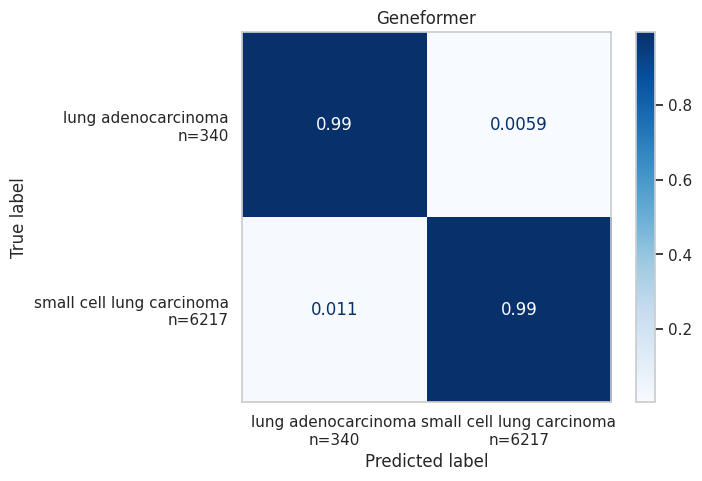

In [62]:
cc.plot_conf_mat(
    conf_mat_dict={"Geneformer": all_metrics_test["conf_matrix"]},
    output_directory="finetuned_model",
    output_prefix="cm_dz_classifier",
    custom_class_order=["lung adenocarcinoma", "small cell lung carcinoma"]
)

### Plot prediction probabilities

Prediction plots visualize model confidence and class separation. Strongly separated predictions support the conclusion that LUAD and SCLC epithelial cells occupy distinct transcriptional states.

<Figure size 1500x1500 with 0 Axes>

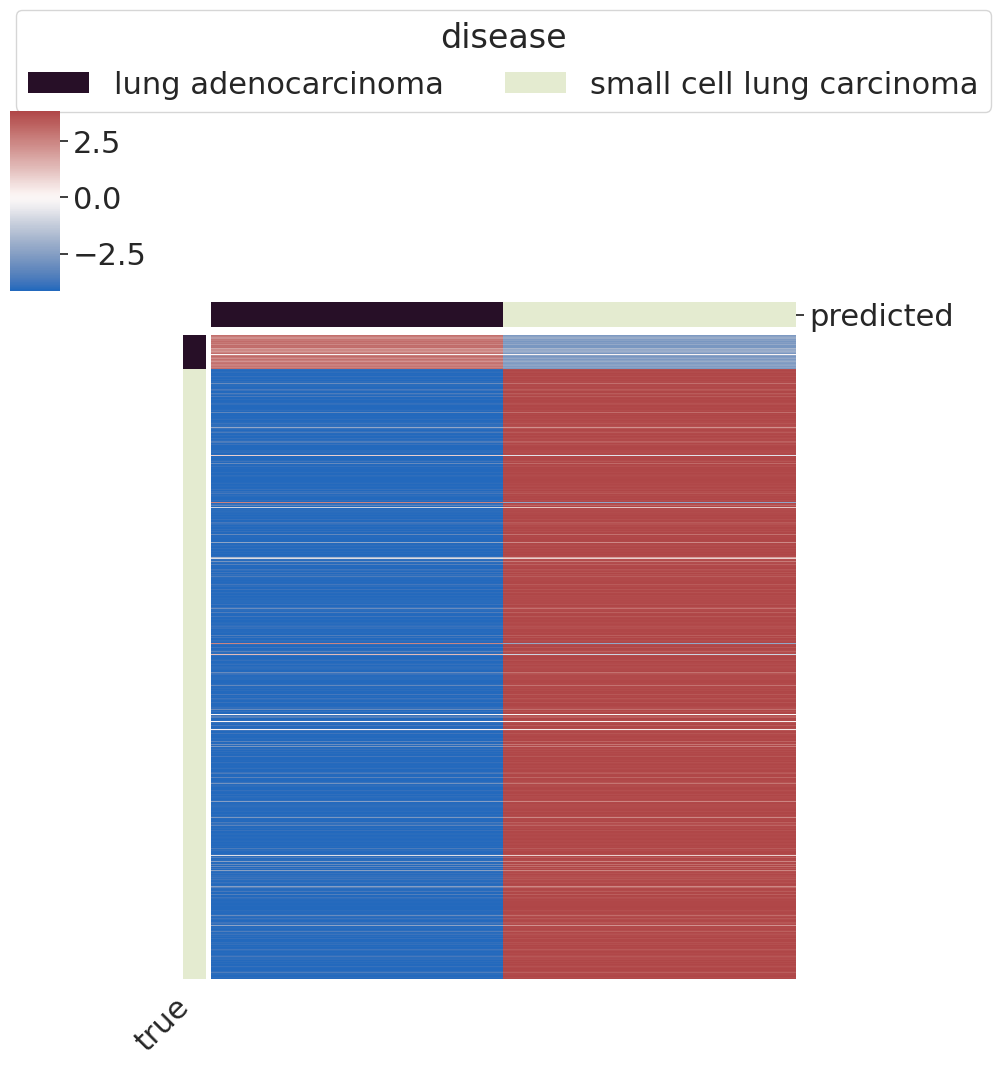

In [63]:
cc.plot_predictions(
    predictions_file="finetuned_model/cm_dz_classifier_pred_dict.pkl",
    id_class_dict_file="finetuned_model/cm_dz_classifier_id_class_dict.pkl",
    title="disease",
    output_directory="finetuned_model",
    output_prefix="cm_dz_classifier",
    custom_class_order=["lung adenocarcinoma", "small cell lung carcinoma"]
)

## 10. Exploratory three-class epithelial classifier

This section includes normal epithelial cells in addition to LUAD and SCLC. It is biologically useful but more technically challenging because the normal group is smaller and donor splitting may be less clean.

# Classification 3

In [84]:
donor_df3 = (
    adata_sub3.obs[["donor_id", "disease"]]
    .drop_duplicates()
    .sort_values("donor_id")
)

print(donor_df3)

                                   donor_id                    disease
Cell                                                                  
RU426B_227303182691099                RU426  small cell lung carcinoma
RU653_T_164761064589214               RU653        lung adenocarcinoma
RU661_T_160440071437027               RU661        lung adenocarcinoma
RU675_N_204213425723118               RU675                     normal
RU675_T_134592140529052               RU675        lung adenocarcinoma
RU676_169151714257187                 RU676        lung adenocarcinoma
RU682_T_126132113828764               RU682        lung adenocarcinoma
RU682_N_169158873934260               RU682                     normal
RU684_T_155971398822774               RU684        lung adenocarcinoma
RU684_N_126776270798243               RU684                     normal
RU685_N_226883234392347               RU685                     normal
RU1038_Sort-Freeze_120786785593067   RU1038        lung adenocarcinoma
RU1057

In [85]:
from sklearn.model_selection import train_test_split

train_eval_df, test_df = train_test_split(
    donor_df3,
    test_size=0.20,
    stratify=donor_df3["disease"],
    random_state=42
)

train_df, eval_df = train_test_split(
    train_eval_df,
    test_size=0.20,
    stratify=train_eval_df["disease"],
    random_state=42
)

train_ids = train_df["donor_id"].tolist()
eval_ids = eval_df["donor_id"].tolist()
test_ids = test_df["donor_id"].tolist()

print("train:", train_ids)
print("eval:", eval_ids)
print("test:", test_ids)

train: ['RU1262', 'RU1311', 'RU1134', 'RU1145', 'RU685', 'RU1057', 'RU1135', 'RU675', 'RU682', 'RU1229', 'RU426', 'RU653', 'RU1195', 'RU1108', 'RU1128', 'RU684', 'RU684', 'RU1271']
eval: ['RU682', 'RU661', 'RU1170', 'RU1061', 'RU1144']
test: ['RU1038', 'RU675', 'RU1066', 'RU1181', 'RU1137', 'RU676']


### Define three-class classifier

The model now predicts normal, LUAD, or SCLC epithelial state. This is more complex than the two-class tumor-only classifier.

In [86]:
from geneformer import Classifier

training_args = {
    "num_train_epochs": 1,
    "learning_rate": 1e-4,
    "per_device_train_batch_size": 12,
    "seed": 42,
}

cc = Classifier(
    classifier="cell",
    cell_state_dict={
        "state_key": "disease",
        "states": "all"
    },
    filter_data=None,
    training_args=training_args,
    max_ncells=None,
    freeze_layers=3,
    num_crossval_splits=1,
    forward_batch_size=32,
    nproc=4,
    model_version="V1"
)

In [87]:
train_test_id_split_dict = {
    "attr_key": "individual",
    "train": train_ids + eval_ids,
    "test": test_ids,
}

train_valid_id_split_dict = {
    "attr_key": "individual",
    "train": train_ids,
    "eval": eval_ids,
}

cc.prepare_data(
    input_data_file="output_data3/cm_tokenized3.dataset",
    output_directory="finetuned_model3",
    output_prefix="lung_classifier3",
    split_id_dict=train_test_id_split_dict
)

Saving the dataset (1/1 shards): 100%|█| 27005/27005 [00:00<00:00, 129008.10 exa
Saving the dataset (1/1 shards): 100%|█| 5616/5616 [00:00<00:00, 148019.38 examp


### Validate three-class classifier

The notebook output showed lower performance than the two-class LUAD/SCLC model, which is expected because adding normal epithelial cells introduces class imbalance and greater biological diversity.

In [90]:
os.environ["WANDB_DISABLED"] = "true"

all_metrics = cc.validate(
    model_directory="../Geneformer-V1-10M",
    prepared_input_data_file="finetuned_model3/lung_classifier3_labeled_train.dataset",
    id_class_dict_file="finetuned_model3/lung_classifier3_id_class_dict.pkl",
    output_directory="finetuned_model3",
    output_prefix="lung_classifier3",
    split_id_dict=train_valid_id_split_dict,
    n_hyperopt_trials=0
)

mkdir: ディレクトリ `finetuned_model3/260611_geneformer_cellClassifier_lung_classifier3/' を作成できません: ファイルが存在します
  0%|                                                     | 0/1 [00:00<?, ?it/s]

****** Validation split: 1/1 ******




Filter (num_proc=4): 100%|███████| 27005/27005 [00:03<00:00, 8815.46 examples/s]

Filter (num_proc=4): 100%|███████| 27005/27005 [00:03<00:00, 8741.93 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ../Geneformer-V1-10M and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/collator_for_classification.py:649: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), 

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.100200,0.315756,0.849627,0.746788



100%|████████████████████████████████████████████| 1/1 [10:12<00:00, 612.12s/it]


In [91]:
all_metrics_test = cc.evaluate_saved_model(
    model_directory="finetuned_model3/260611_geneformer_cellClassifier_lung_classifier3/ksplit1/",
    id_class_dict_file="finetuned_model3/lung_classifier3_id_class_dict.pkl",
    test_data_file="finetuned_model3/lung_classifier3_labeled_test.dataset",
    output_directory="finetuned_model3",
    output_prefix="lung_classifier3"
)

100%|█████████████████████████████████████████| 176/176 [01:30<00:00,  1.94it/s]


<Figure size 1000x1000 with 0 Axes>

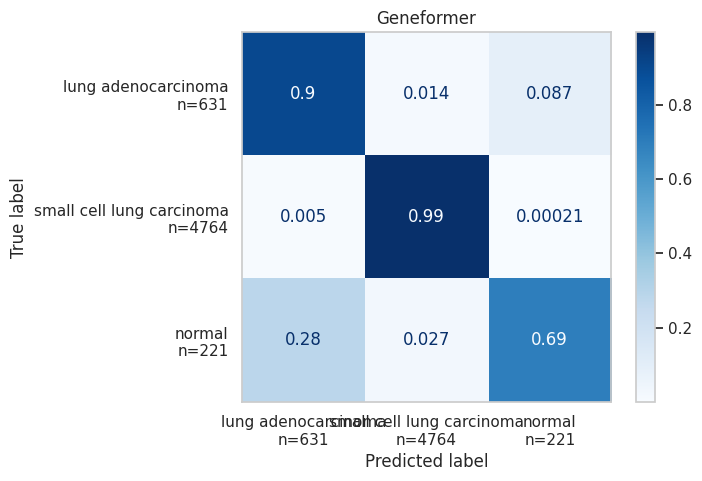

In [92]:
cc.plot_conf_mat(
    conf_mat_dict={"Geneformer": all_metrics_test["conf_matrix"]},
    output_directory="finetuned_model3",
    output_prefix="lung_classifier3",
    custom_class_order=["lung adenocarcinoma", "small cell lung carcinoma", "normal"]
)

<Figure size 1500x1500 with 0 Axes>

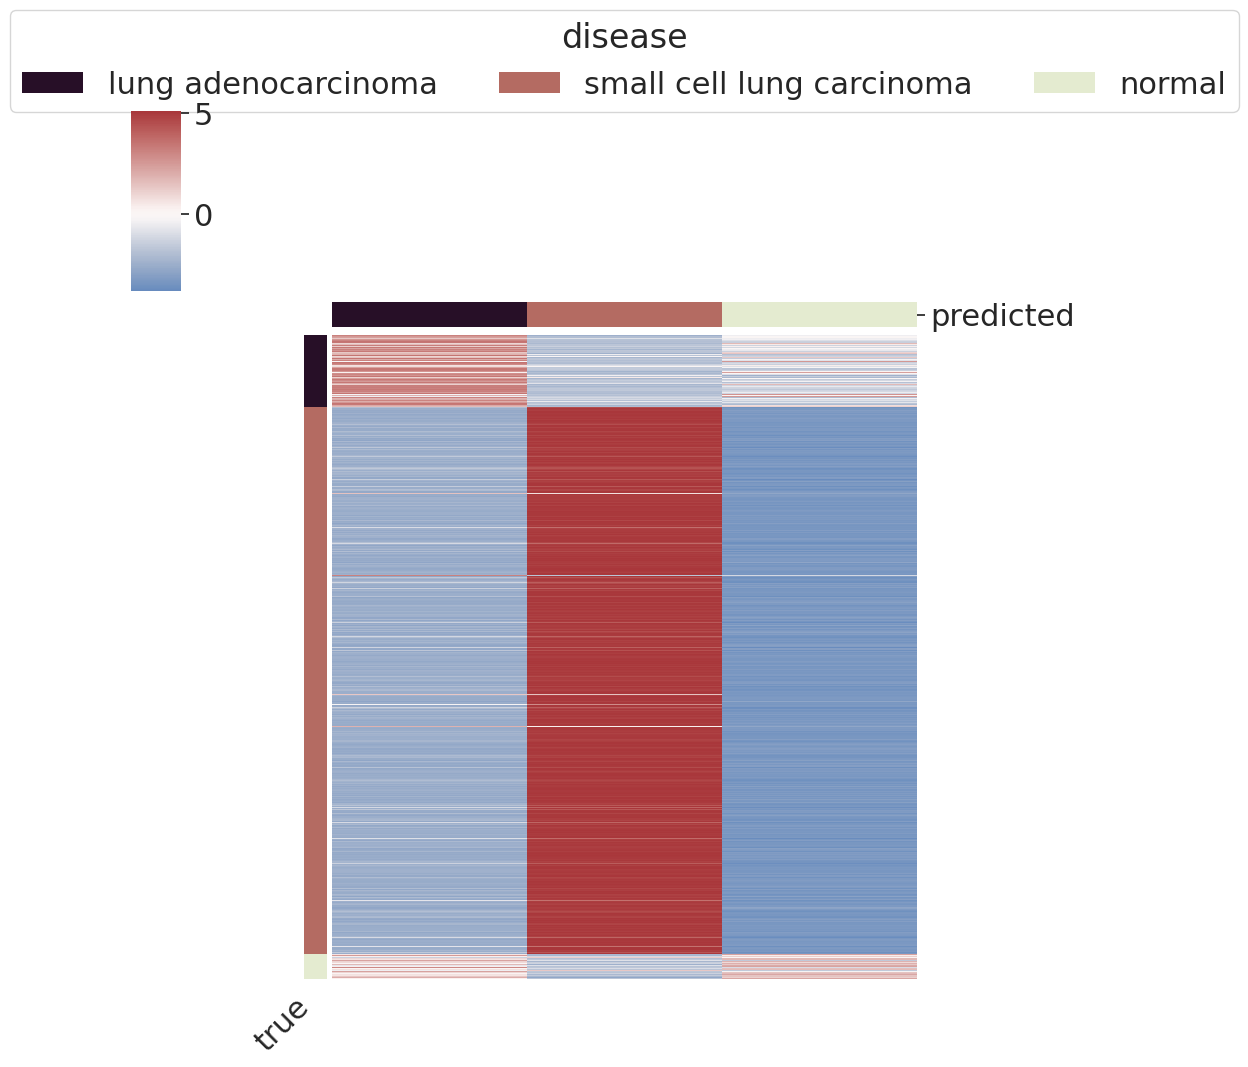

In [94]:
cc.plot_predictions(
    predictions_file="finetuned_model3/lung_classifier3_pred_dict.pkl",
    id_class_dict_file="finetuned_model3/lung_classifier3_id_class_dict.pkl",
    title="disease",
    output_directory="finetuned_model3",
    output_prefix="lung_classifier3",
    custom_class_order=["lung adenocarcinoma", "small cell lung carcinoma", "normal"]
)

## 11. Extract fine-tuned epithelial embeddings

Embeddings are compact numerical representations of each cell learned by the fine-tuned Geneformer model. They can be visualized with UMAP/heatmaps and used for downstream perturbation analysis.

# Get embedding

### Extract embeddings from the LUAD/SCLC classifier

This extracts cell-level embeddings from the fine-tuned two-class epithelial classifier. In this run, embeddings were generated for 31,258 epithelial cells.

In [99]:
from geneformer import EmbExtractor
embex = EmbExtractor(
    model_type="CellClassifier",
    num_classes=2,
    filter_data=None,
    max_ncells=None,
    emb_layer=-1,
    emb_label=["disease", "individual"],
    labels_to_plot=["disease", "individual"],
    forward_batch_size=256,
    nproc=4,
    model_version="V1",
)

embs = embex.extract_embs(
    model_directory="finetuned_model/260611_geneformer_cellClassifier_cm_dz_classifier/ksplit1/",
    input_data_file="output_data/cm_tokenized.dataset",
    output_directory="embed_data",
    output_prefix="finetuned_embs"
)

print(type(embs))
try:
    print(embs.shape)
except Exception:
    pass

model_version selected as V1 so changing emb_mode from 'cls' to 'cell' as V1 models do not have a <cls> token.
100%|█████████████████████████████████████████| 123/123 [02:16<00:00,  1.11s/it]


<class 'pandas.core.frame.DataFrame'>
(31258, 258)


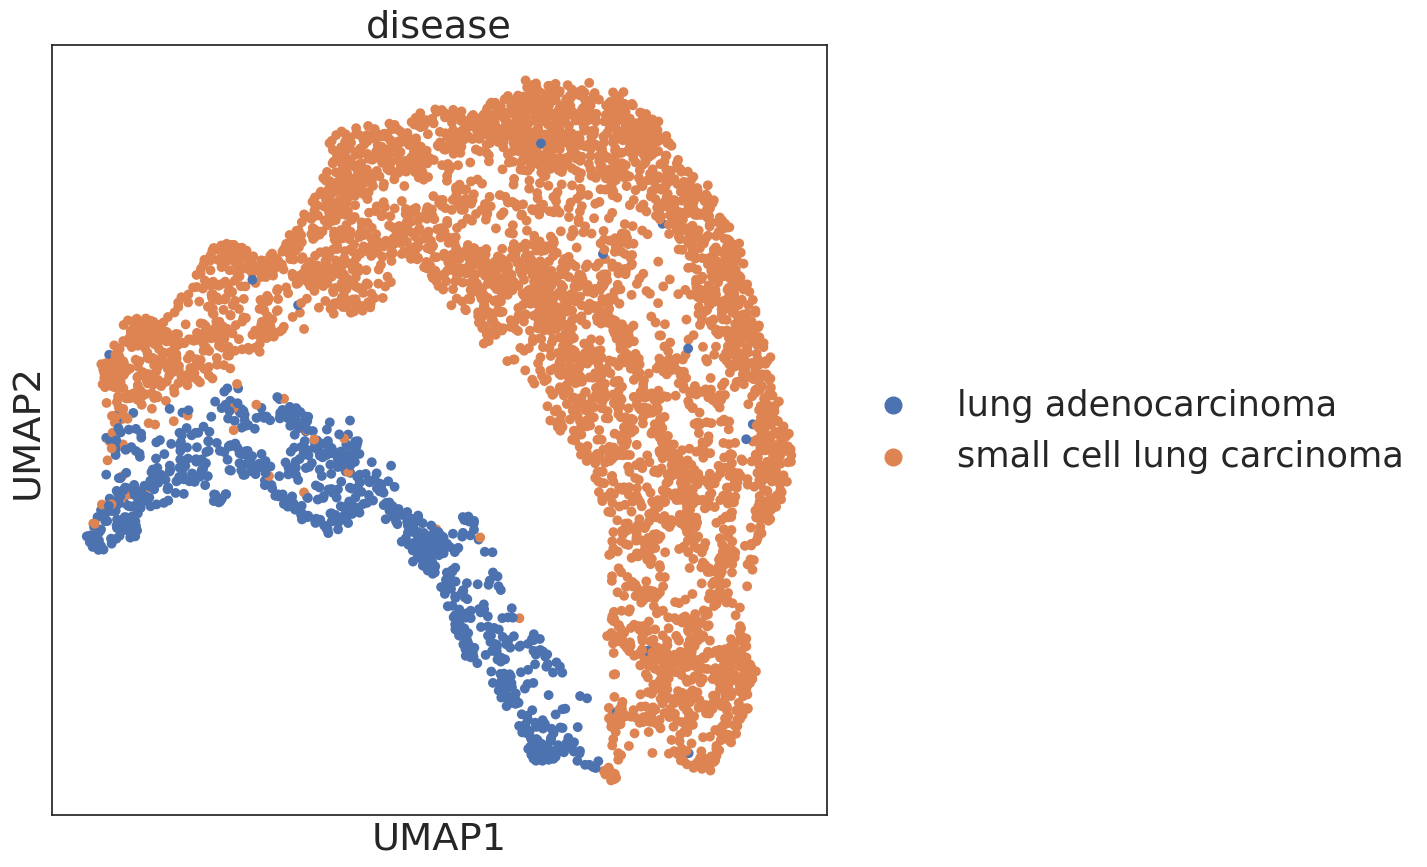

<Figure size 1000x1000 with 0 Axes>

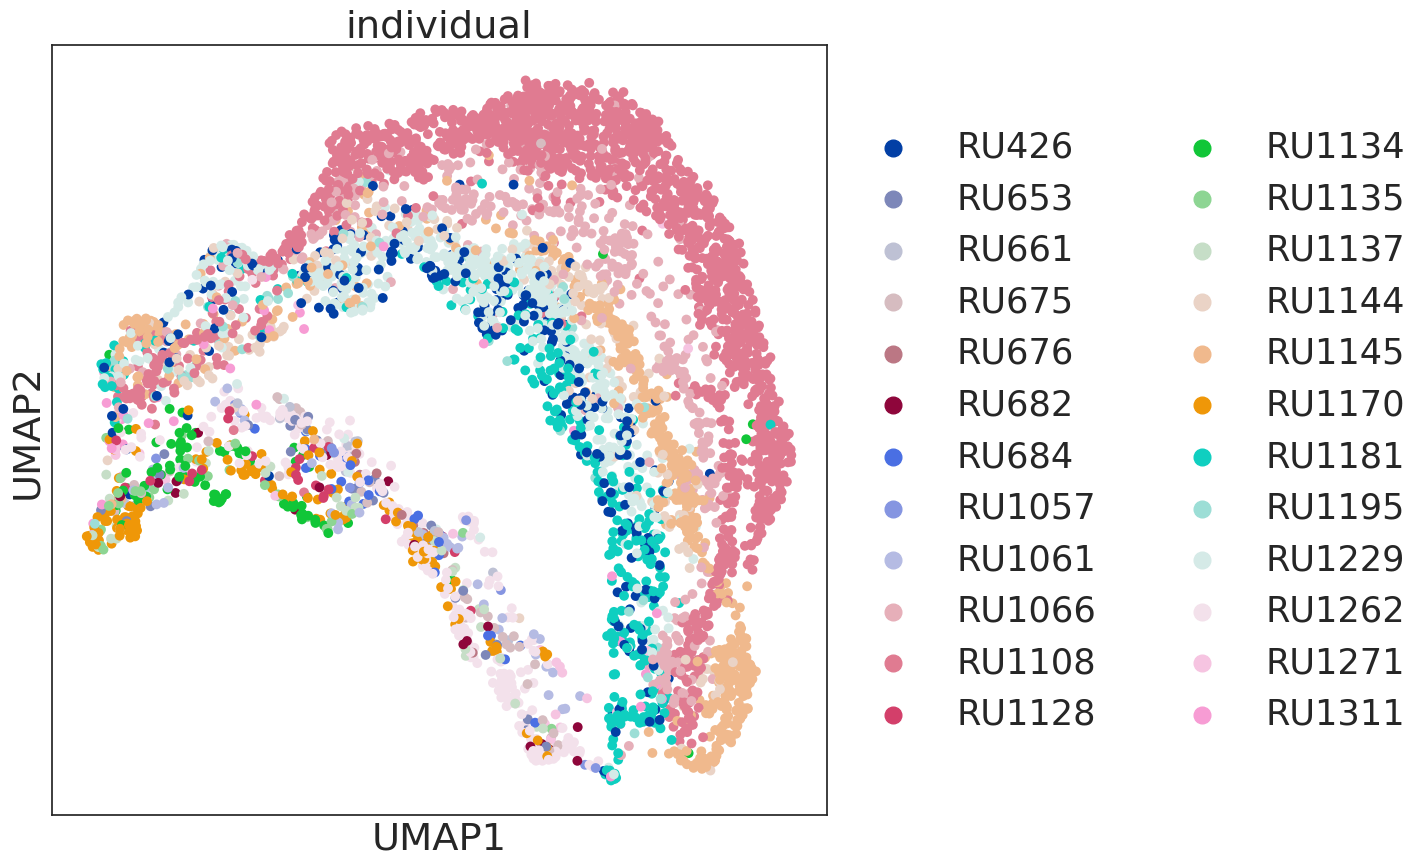

/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1000x1000 with 0 Axes>

<Figure size 2250x2250 with 0 Axes>

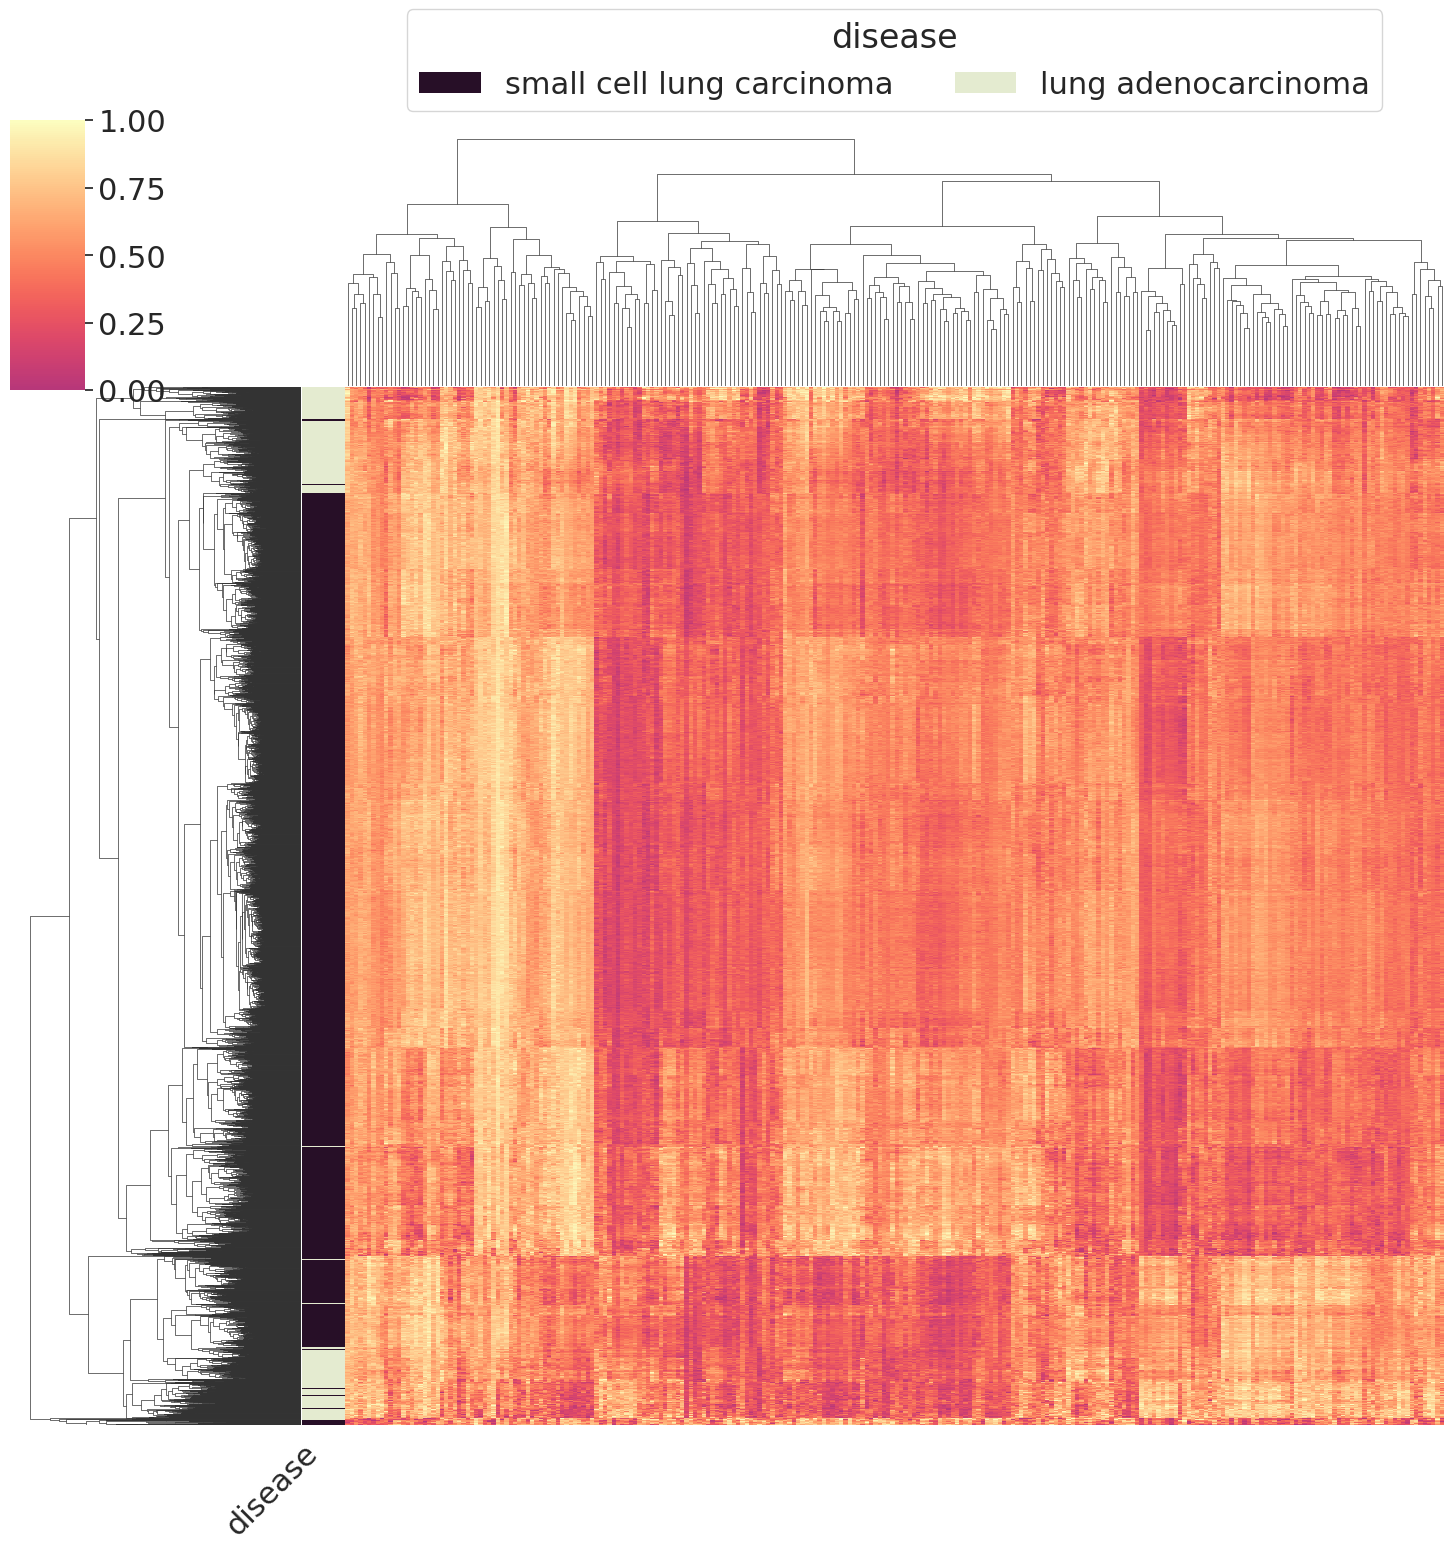

/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1000x1000 with 0 Axes>

<Figure size 2250x2250 with 0 Axes>

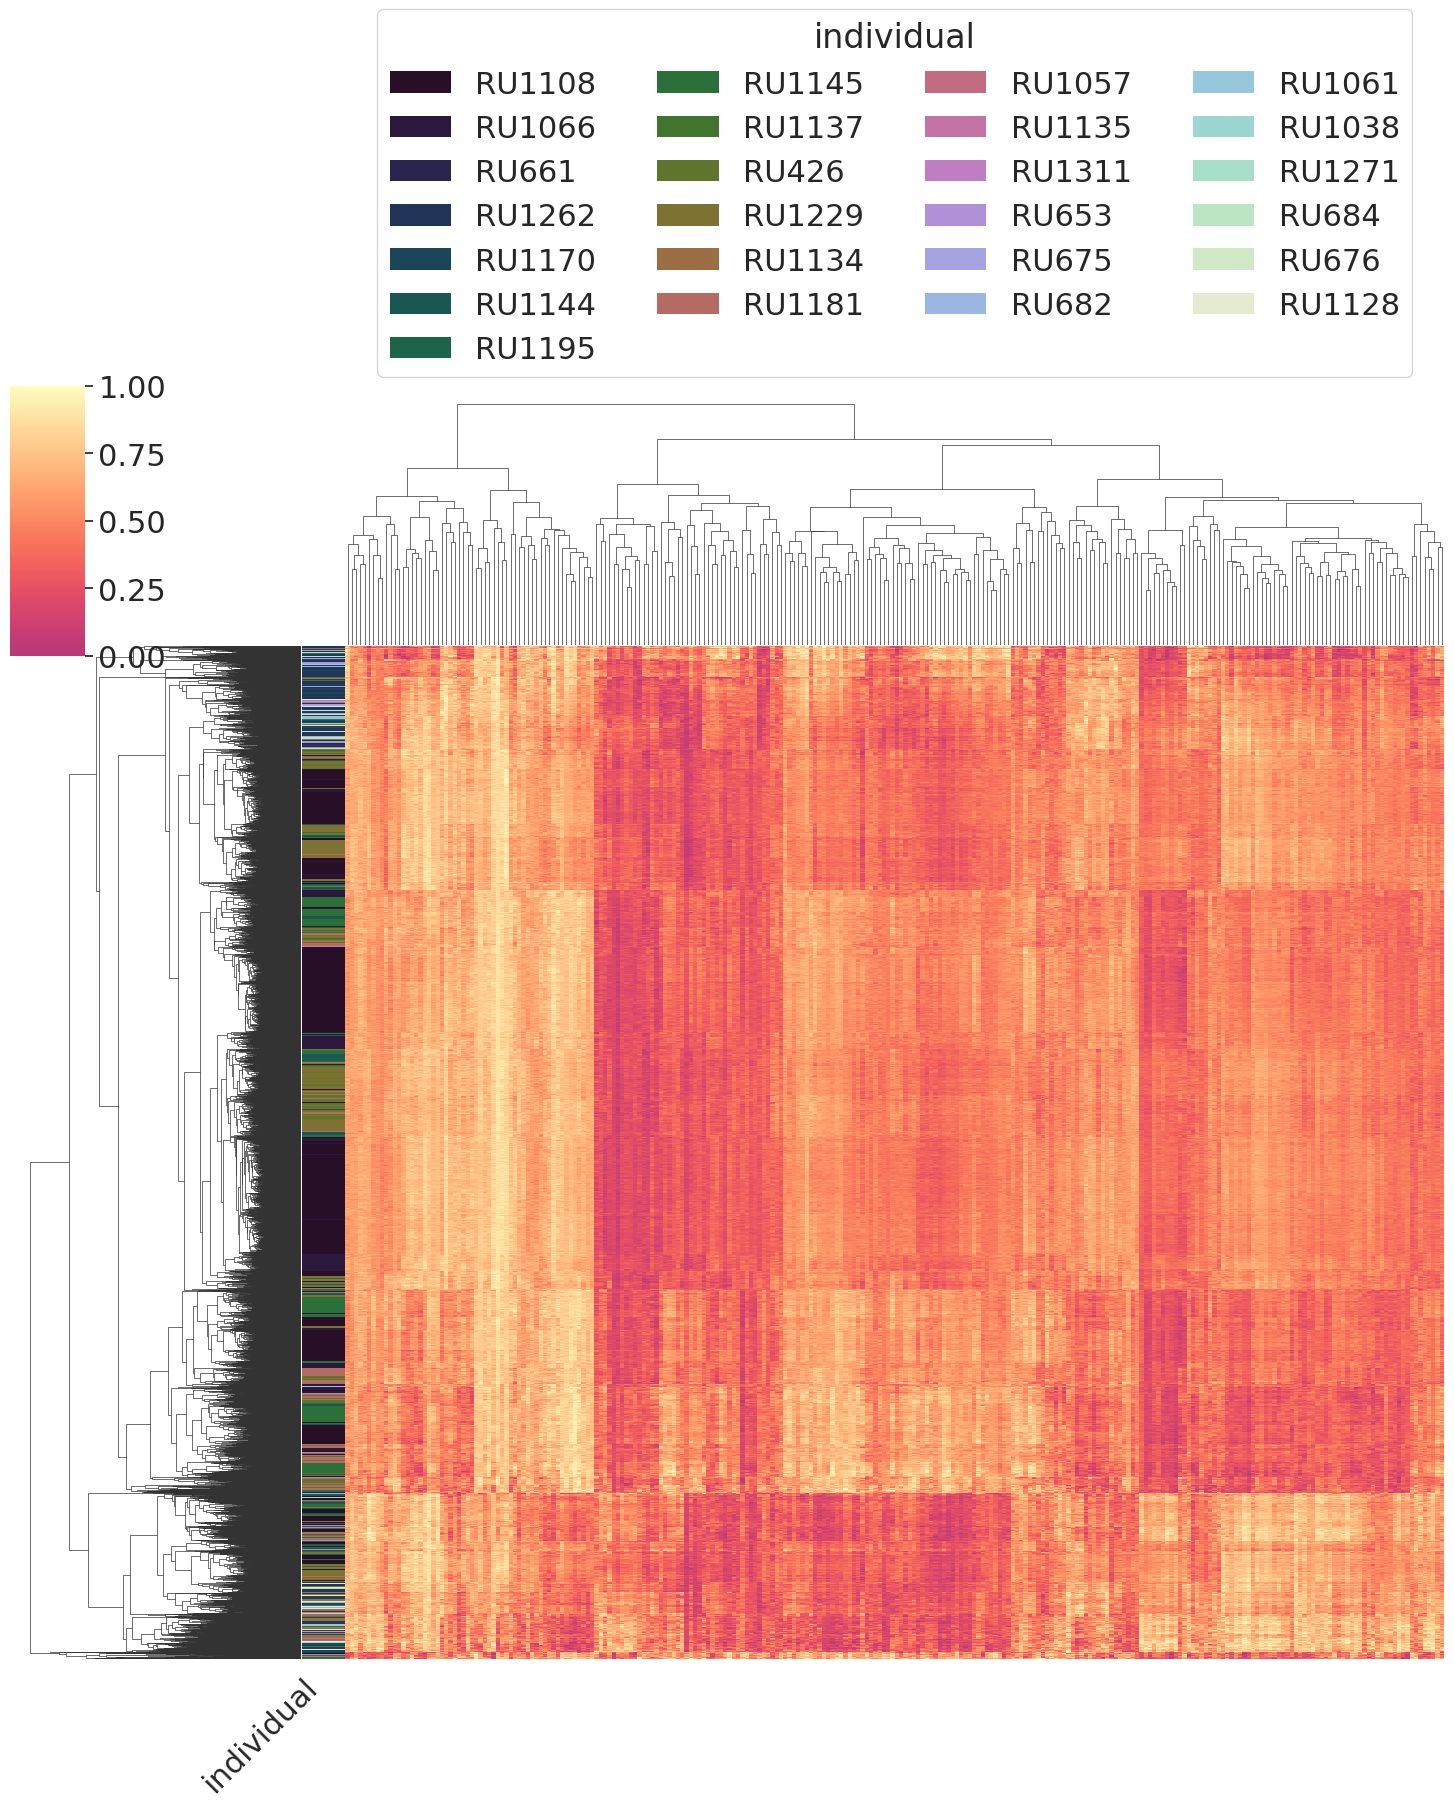

<Figure size 1000x1000 with 0 Axes>

In [100]:
embex.plot_embs(
    embs=embs,
    plot_style="umap",
    output_directory="embed_data",
    output_prefix="emb_umap",
    max_ncells_to_plot=5000,
)

embex.plot_embs(
    embs=embs,
    plot_style="heatmap",
    output_directory="embed_data",
    output_prefix="emb_heatmap",
    max_ncells_to_plot=5000,
)

## 12. In silico perturbation: LUAD to SCLC transition

This section asks a mechanistic question: which gene overexpression perturbations shift LUAD epithelial cells toward an SCLC-like state in Geneformer embedding space?

# pertubation

### Define disease-state transition

The start state is LUAD and the goal state is SCLC. Geneformer computes mean state embeddings for these classes, then evaluates whether perturbing each gene moves cells toward the SCLC goal state.

In [105]:
cell_states_to_model = {
    "state_key": "disease",
    "start_state": "lung adenocarcinoma",
    "goal_state": "small cell lung carcinoma",
    "alt_states": [],
}

embex = EmbExtractor(
    model_type="CellClassifier",
    num_classes=2,
    filter_data=None,
    max_ncells=5000,
    emb_layer=-1,
    summary_stat="exact_mean",
    # emb_label=["disease", "individual"],
    # labels_to_plot=["disease", "individual"],
    forward_batch_size=256,
    nproc=4,
    model_version="V1",
)

state_embs_dict = embex.get_state_embs(
    cell_states_to_model,
    model_directory="finetuned_model/260611_geneformer_cellClassifier_cm_dz_classifier/ksplit1/",
    input_data_file="output_data/cm_tokenized.dataset",
    output_directory="embed_data",
    output_prefix="state_embs",
)

state_embs_dict.keys()

model_version selected as V1 so changing emb_mode from 'cls' to 'cell' as V1 models do not have a <cls> token.
100%|███████████████████████████████████████████| 20/20 [00:23<00:00,  1.16s/it]


dict_keys(['lung adenocarcinoma', 'small cell lung carcinoma'])

### Run all-gene overexpression perturbation

Each detected gene is computationally overexpressed one at a time. This is a hypothesis-generating screen for genes associated with SCLC-like transcriptional transition.

In [ ]:
# In silico perturbation: overexpress each gene and evaluate LUAD-to-SCLC shift
from geneformer import InSilicoPerturber

perturbation_type = "overexpress"
genes_to_perturb = "all"

isp = InSilicoPerturber(
    perturb_type=perturbation_type,
    genes_to_perturb=genes_to_perturb,
    model_type="CellClassifier",
    num_classes=2,
    emb_mode="cell",
    cell_states_to_model=cell_states_to_model,
    state_embs_dict=state_embs_dict,
    max_ncells=2500,
    emb_layer=-1,
    forward_batch_size=256,
    nproc=4,
    model_version="V1",
)

isp.perturb_data(
    model_directory="finetuned_model/260611_geneformer_cellClassifier_cm_dz_classifier/ksplit1/",
    input_data_file="output_data/cm_tokenized.dataset",
    output_directory="pert_overexpress",
    output_prefix="overexpress_to_sclc",
)

### Compute perturbation statistics

This step summarizes perturbation effects across cells and calculates significance/FDR. Genes are ranked by their shift toward the SCLC goal state.

In [108]:
# Perturbation statistics: rank genes by goal-state shift and FDR
from geneformer import InSilicoPerturberStats
ispstats = InSilicoPerturberStats(
    mode="goal_state_shift",
    genes_perturbed="all",
    combos=0,
    anchor_gene=None,
    cell_states_to_model=cell_states_to_model,
    model_version="V1",
)

ispstats.get_stats(
    "pert_overexpress",
    None,
    "pert_overexpress_result",
    "isd",
)

  0%|                                                 | 0/15531 [00:00<?, ?it/s]/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/geneformer/in_silico_perturber_stats.py:436: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cos_sims_full_df = pd.concat([cos_sims_full_df, cos_sims_df_i])
100%|█████████████████████████████████████| 15531/15531 [03:27<00:00, 74.86it/s]


In [109]:
results = pd.read_csv("pert_overexpress_result/isd.csv", index_col=0)
results

,Gene,Gene_name,Ensembl_ID,Shift_to_goal_end,Goal_end_vs_random_pval,Goal_end_FDR,N_Detections,Sig
6394,7260,BLK,ENSG00000136573,0.005634,3.816868e-03,4.931721e-02,8,1
3321,3698,NCAPG,ENSG00000109805,0.002922,1.140875e-03,2.079687e-02,9,1
10583,12286,SFTPC,ENSG00000168484,0.002848,1.175188e-31,2.027983e-28,588,1
15360,23875,CCL5,ENSG00000271503,0.002511,2.724857e-10,5.224661e-08,85,1
5884,6681,TPT1,ENSG00000133112,0.002369,3.866017e-78,1.200862e-74,1207,1
...,...,...,...,...,...,...,...,...
7703,8794,TAAR6,ENSG00000146383,-0.014458,8.452721e-02,3.358384e-01,1,0
8845,10175,CD1E,ENSG00000158488,-0.014668,8.452097e-02,3.358384e-01,1,0
12855,15478,FLRT2,ENSG00000185070,-0.015861,8.443985e-02,3.356630e-01,1,0
9781,11307,IL31RA,ENSG00000164509,-0.018636,1.564017e-01,4.504941e-01,2,0


### Volcano-like perturbation plot

This plot shows each gene by effect size and statistical significance. Genes to the right shift LUAD epithelial cells toward the SCLC state.

/home/petadimensionlab/workspace/Geneformer/geneformer/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


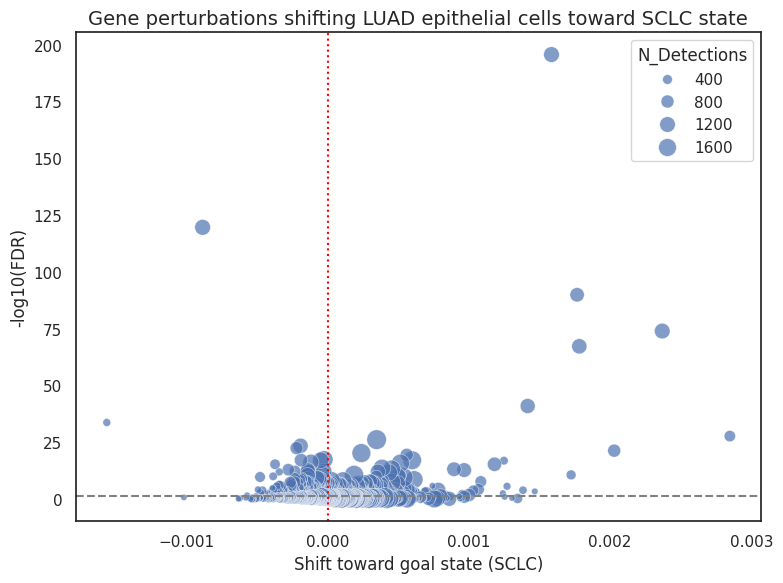

In [112]:
df = results.copy()
df = df[df["N_Detections"] > 100]
df["minus_log10_fdr"] = -np.log10(df["Goal_end_FDR"])

plt.figure(figsize=(8,6))
sns.set_theme(style="white")

sns.scatterplot(data=df,
                x="Shift_to_goal_end", y="minus_log10_fdr", size="N_Detections",
                sizes=(20,200), alpha=0.7
               )
plt.axvline(0, color="red", linestyle=":")
plt.axhline(-np.log10(0.05), color="gray", linestyle="--")

plt.title("Gene perturbations shifting LUAD epithelial cells toward SCLC state", fontsize=14)
plt.xlabel("Shift toward goal state (SCLC)", fontsize=12)
plt.ylabel("-log10(FDR)", fontsize=12)

plt.tight_layout()
plt.show()

### Top perturbation candidates

This plot highlights genes with the largest absolute perturbation shifts after filtering by FDR and detection frequency. These are computational candidates and require biological filtering and validation.

        Gene Gene_name       Ensembl_ID  Shift_to_goal_end  \
10583  12286     SFTPC  ENSG00000168484           0.002848   
5884    6681      TPT1  ENSG00000133112           0.002369   
4824    5433      SLPI  ENSG00000124107           0.002029   
13193  15993      PTMA  ENSG00000187514           0.001782   
1185    1319      ACTB  ENSG00000075624           0.001767   
...      ...       ...              ...                ...   
2884    3197     ITGB8  ENSG00000105855          -0.000506   
13338  16229  RALGAPA2  ENSG00000188559          -0.000570   
10489  12172      FTH1  ENSG00000167996          -0.000884   
9438   10887    S100A9  ENSG00000163220          -0.001563   
10218  11842       B2M  ENSG00000166710          -0.003171   

       Goal_end_vs_random_pval   Goal_end_FDR  N_Detections  Sig  
10583             1.175188e-31   2.027983e-28           588    1  
5884              3.866017e-78   1.200862e-74          1207    1  
4824              4.700009e-25   5.213989e-22         

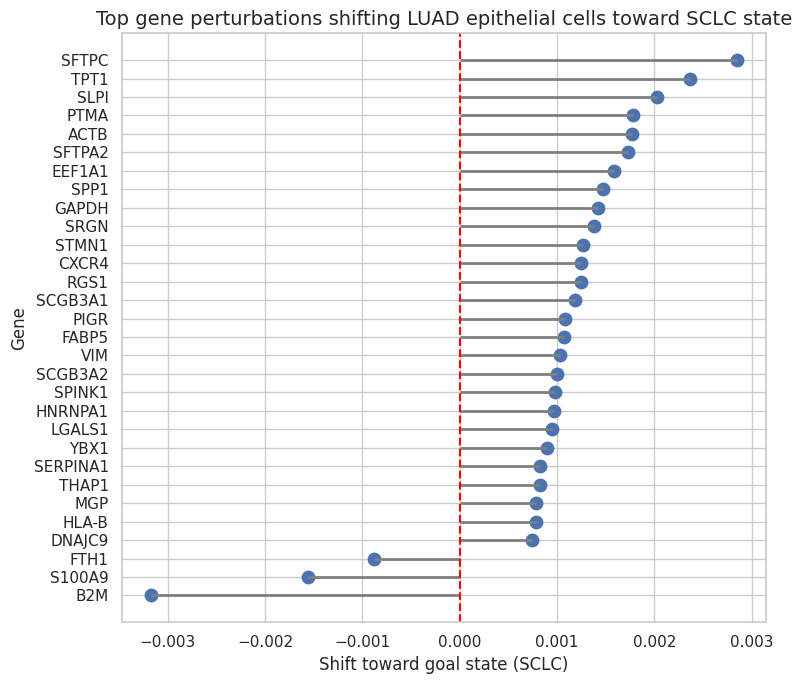

In [113]:
df = results.copy()
df = df[df["Goal_end_FDR"] < 0.05]
df = df[df["N_Detections"] > 100]
print(df)

n_top_genes = 30
df_plot = (
    df.reindex(
        df["Shift_to_goal_end"]
        .abs()
        .sort_values(ascending=False)
        .index
    )
    .head(n_top_genes)
    .sort_values("Shift_to_goal_end")
)

plt.figure(figsize=(8, 7))
sns.set_theme(style="whitegrid")

plt.scatter(df_plot["Shift_to_goal_end"],
            df_plot["Gene_name"],
            s=80
           )
plt.hlines(y=df_plot["Gene_name"], xmin=0, xmax=df_plot["Shift_to_goal_end"], color="gray", linewidth=2)
plt.axvline(x=0, color="red", linestyle="--", linewidth=1.5)

plt.title("Top gene perturbations shifting LUAD epithelial cells toward SCLC state", fontsize=14)
plt.xlabel("Shift toward goal state (SCLC)", fontsize=12)
plt.ylabel("Gene", fontsize=12)

plt.tight_layout()
plt.show()


# Integrated Interpretation

## Cross-compartment comparison

| Feature | T cells | Epithelial cells |
|----------|----------|----------|
| Disease classification | Moderate | Strong |
| LUAD vs SCLC separation | Limited | Excellent |
| Biological signal | Immune state | Tumor lineage |
| Translational relevance | Immunotherapy | Tumor biology |

## Biological model

Tumor epithelial cells encode the primary disease-lineage program.

T cells reflect downstream immune remodeling and shared cancer-associated states.

## Recommended next steps

1. Repeat analyses using Geneformer V2 104M.
2. Add external healthy lung datasets (HLCA).
3. Perform pathway enrichment on perturbation hits.
4. Investigate ASCL1, NEUROD1, POU2F3, YAP1, MYC and NOTCH signaling.
5. Explore PDCD1, CTLA4, TIGIT, LAG3, IFNG and TNF programs in T cells.
6. Validate top perturbation candidates experimentally.
